# Lección 17.3 · Modelos de lenguaje de proteínas: atención, ESM-2 y efectos de mutaciones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-17-machine-learning/17.3_modelos_lenguaje_proteinas.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 17 — Machine Learning e IA en bioinformática** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lecciones 4.2–4.3 (PWM y HMM de perfil), 15.1 (PDB y contactos), 17.1 (clasificadores y validación) y 17.2 (redes neuronales) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** con palabras sencillas por qué adivinar un aminoácido oculto obliga a aprender estructura y evolución.
2. **Calcular a mano** la atención de producto escalar escalado ($\mathrm{softmax}(QK^\top/\sqrt{d_k})V$) sobre un
   péptido de cuatro residuos y **justificar** la división entre $\sqrt{d_k}$.
3. **Escribir** la pérdida del modelado de lenguaje enmascarado (MLM) y la (pseudo)perplejidad, y **medirlas** con un
   modelo ESM-2 real sobre la ubiquitina humana.
4. **Predecir contactos** a partir de los mapas de atención de ESM-2 y **evaluarlos** contra la estructura cristalográfica 1UBQ
   (precisión de los $L$ pares mejor puntuados).
5. **Obtener *embeddings*** de proteínas completas y **compararlos** con espectros de $k$-mers para agrupar 150 proteínas reales
   de cinco familias de UniProt (PCA, UMAP, vecino más cercano).
6. **Puntuar sin supervisión** las $19\times76$ mutaciones puntuales de la ubiquitina con el marginal enmascarado y
   **contrastar** esas predicciones con un experimento real de mutagénesis profunda (Roscoe et al., 2013).
7. **Reconocer** los límites de estos modelos: fuga de información, sesgo de representación y puntuaciones no calibradas.

## 🗺️ Mapa de la clase

1. Completar la palabra que falta: la idea de la clase
2. 🧪 Los datos de la clase: ubiquitina, su estructura 1UBQ, 150 proteínas de UniProt y un experimento de mutagénesis
3. Atención: cada residuo mira a todos los demás (ejemplo resuelto «Atención con cuatro residuos»)
4. ¿Por qué dividir entre $\sqrt{d_k}$? Un experimento numérico
5. Modelado de lenguaje enmascarado y perplejidad con ESM-2 (🎬 animación)
6. Qué aprende el modelo (I): contactos a partir de la atención (📊 interactivo, 🎬 animación)
7. Qué aprende el modelo (II): *embeddings* de proteínas completas (📊 interactivo)
8. Predicción de efectos de mutaciones sin supervisión (ejemplo resuelto «Leer el paisaje de la ubiquitina», 📊 interactivo)
9. 🧬 Caso real: ¿acierta el modelo frente a 1195 mutantes medidos en levadura?
10. Riesgos y limitaciones
11. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección **«Modelos de lenguaje de proteínas (ESM)»** del capítulo 17 del libro. Usamos su
> notación ($\mathbf{h}_i$, $\mathbf{q}_i$, $\mathbf{k}_i$, $\mathbf{v}_i$, $W_Q$, $W_K$, $W_V$, $d_k$, $A_{ij}$, $\mathbf{z}_i$,
> $M$, $x_{\setminus M}$, $p_{\boldsymbol\theta}$, $\mathrm{PPL}$, $\mathbf{e}(x)$, $s(x^{\text{mut}})$), sus ecuaciones y sus
> dos ejemplos resueltos con las mismas cifras. El libro usa ESM-2 de **650 millones** de parámetros (2,5 GB); aquí
> ejecutamos en vivo, en CPU, su hermano pequeño de **35 millones** (`esm2_t12_35M_UR50D`, 134 MB) y cargamos los
> resultados del modelo grande que calculó el libro para comparar ambos.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, math, time, socket
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=60):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def course_npz(name):
    return np.load(io.BytesIO(course_bytes(name)), allow_pickle=False)

# Alfabeto de 20 aminoácidos en el orden que usa el libro (cargados → polares → hidrofóbicos)
AA = "RHKDESTNQCGPAVILMFYW"
UBQ_HUMAN = "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"
UBQ_YEAST = "MQIFVKTLTGKTITLEVESSDTIDNVKSKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"
L = len(UBQ_HUMAN)
print("Ubiquitina humana:", L, "residuos · diferencias con la de levadura:",
      [f"{a}{i+1}{b}" for i, (a, b) in enumerate(zip(UBQ_HUMAN, UBQ_YEAST)) if a != b])

Entorno listo ✔  |  Colab: False


Ubiquitina humana: 76 residuos · diferencias con la de levadura: ['P19S', 'E24D', 'A28S']


### Cargar ESM-2 (modelo pequeño, en CPU)

Usamos la biblioteca oficial [`fair-esm`](https://github.com/facebookresearch/esm) de Meta AI. En Colab hay que instalarla
(unos segundos); el modelo de 35 M de parámetros (134 MB) se descarga la primera vez. Si la descarga fallara (red lenta,
servidor caído), la clase **no se detiene**: cargamos una copia de las salidas del mismo modelo guardada en el repositorio
(`data/173_esm2_35M_cache.npz`) y todo lo demás funciona igual.

In [2]:
# Instalar fair-esm si hace falta (Colab no la trae)
try:
    import esm
except ImportError:
    %pip install -q fair-esm
    import esm
import torch
torch.set_grad_enabled(False)          # sólo inferencia: no necesitamos gradientes
socket.setdefaulttimeout(90)

t0 = time.time()
try:
    model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
    model.eval()
    batch_converter = alphabet.get_batch_converter()
    ESM_LIVE = True
    n_par = sum(p.numel() for p in model.parameters())
    print(f"ESM-2 35M cargado en {time.time() - t0:.1f} s · {n_par/1e6:.1f} M de parámetros · "
          f"{model.num_layers} capas × {model.attention_heads} cabezas · d = {model.embed_dim}")
except Exception as err:
    ESM_LIVE = False
    print(f"⚠️ No se pudo cargar ESM-2 ({err}). Uso las salidas precalculadas del mismo modelo.")

CACHE35 = course_npz("173_esm2_35M_cache.npz")      # respaldo (y comprobación) del modelo pequeño
BOOK650 = course_npz("173_ubq_esm2_650M.npz")        # cifras del libro: ESM-2 650M sobre la ubiquitina humana
print("Respaldo 35M:", {k: CACHE35[k].shape for k in CACHE35.files})
print("Libro 650M :", {k: BOOK650[k].shape for k in BOOK650.files})

ESM-2 35M cargado en 0.2 s · 33.5 M de parámetros · 12 capas × 20 cabezas · d = 480
Respaldo 35M: {'aa': (20,), 'logp20_human': (76, 20), 'logp20_yeast': (76, 20), 'contacts': (76, 76), 'attn': (12, 20, 78, 78), 'emb': (150, 480)}
Libro 650M : {'aa': (20,), 'LLR': (20, 76), 'logp20': (76, 20), 'contacts': (76, 76)}


---

## 1. Completar la palabra que falta

En la frase «El gato persiguió al ______ por el jardín» casi cualquiera escribiría «ratón». Nadie consultó una regla
gramatical: bastó haber leído mucho. Y quien acierta sistemáticamente este tipo de huecos ha aprendido, sin proponérselo,
sintaxis («al» pide un sustantivo masculino), semántica (los gatos persiguen cosas pequeñas que se mueven) y bastante sobre
gatos.

Ahora hagamos el mismo juego con proteínas. Tomemos un fragmento real de la ubiquitina humana y ocultemos un residuo:

```
... P  D  Q  Q  R  L  ?  F  A  G  K  Q  L ...
    38 39 40 41 42 43 44 45 46 47 48 49 50
```

¿Qué aminoácido va en la posición 44? Un modelo que sólo contara frecuencias diría «leucina, que es la más común». Pero la
posición 44 está en el **parche hidrofóbico** de la ubiquitina, la superficie que reconocen decenas de proteínas que se
unen a ella; para acertar hay que «saber» que ese residuo está rodeado de otros hidrofóbicos en la estructura
tridimensional. La respuesta correcta es **isoleucina** (I44).

La evolución ha escrito cientos de millones de «textos» en el alfabeto de 20 letras de las proteínas, y la selección natural
ha actuado como un editor implacable: sólo sobreviven las secuencias que se pliegan y funcionan. Un **modelo de lenguaje de
proteínas** es una red neuronal que juega millones de veces a completar huecos en esos textos. Al hacerlo aprende, sin que
nadie se lo enseñe, qué residuos se tocan, qué posiciones son intocables y qué proteínas son parientes.

| En el lenguaje humano | En las proteínas |
|---|---|
| Letras y palabras | Los 20 aminoácidos (*tokens*) |
| Frases de un libro | Secuencias de UniProt/UniRef |
| Gramática que nadie escribió | Restricciones de plegamiento y función impuestas por la selección |
| Rellenar «______» en una frase | Predecir el aminoácido oculto (`<mask>`) |
| Una palabra rara en una frase suena mal | Una mutación «improbable» suele ser perjudicial |

Las PWM y los HMM de perfil de las Lecciones 4.2 y 4.3 ya explotaban estos patrones, pero dentro de **una** familia alineada. Un modelo
de lenguaje intenta aprenderlos para **todas** las proteínas a la vez, sin alineamientos ni etiquetas.

> 🧭 **Contexto práctico.** Cada genoma humano secuenciado en una consulta de genética trae cientos de variantes de sentido
> erróneo nunca vistas antes. Los modelos de esta clase (ESM1b, ESM-2) ya se usan para priorizarlas: Brandes et al. (2023)
> puntuaron las ~450 millones de variantes de sentido erróneo posibles del proteoma humano. Hoy aprenderemos a calcular esas
> puntuaciones y, sobre todo, a desconfiar de ellas con criterio.

---

## 2. 🧪 Los datos de la clase

Trabajaremos con cuatro fuentes reales:

| Datos | Origen | Para qué |
|---|---|---|
| Ubiquitina humana (76 aa) y su estructura cristalográfica **1UBQ** (1,8 Å) | RCSB PDB (copia del curso `data/151_1UBQ.pdb.gz`, ya usada en la Lección 15.1) | Secuencia de trabajo y contactos reales |
| 150 proteínas revisadas de UniProt, 30 por familia (globinas, citocromos c, peptidasas S1, HSP20, tiorredoxinas) | UniProt REST; exactamente las mismas que eligió el libro (`data/173_uniprot_familias.tsv.gz`) | *Embeddings* frente a $k$-mers |
| Salidas de ESM-2 **650M** sobre la ubiquitina y sus *embeddings* de las 150 proteínas | Calculadas por el libro (`figuras/cap17/generar.py`), guardadas en `data/173_*650M*.npz` | Reproducir las cifras del libro |
| Mutagénesis profunda de la ubiquitina de levadura: tasa de crecimiento de 1195 mutantes puntuales | Roscoe et al. (2013), *J. Mol. Biol.* 425:1363, en la versión curada de ProteinGym (`data/173_roscoe2013_ubiquitin_dms.csv`) | Contrastar las predicciones sin supervisión con el experimento |

La ubiquitina es una proteína pequeña y famosa: se une covalentemente, por su glicina C-terminal (G76), a otras proteínas
para marcarlas, por ejemplo, para su degradación en el proteasoma. Es una de las proteínas más conservadas de los eucariotas:
la humana y la de levadura difieren sólo en **3 de 76** posiciones.

In [3]:
# Estructura 1UBQ: coordenadas del Cβ (Cα para la glicina) de cada residuo de la cadena A
AA3TO1 = dict(ALA="A", ARG="R", ASN="N", ASP="D", CYS="C", GLN="Q", GLU="E", GLY="G", HIS="H", ILE="I", LEU="L",
              LYS="K", MET="M", PHE="F", PRO="P", SER="S", THR="T", TRP="W", TYR="Y", VAL="V")
pdb_text = gzip.decompress(course_bytes("151_1UBQ.pdb.gz", "https://files.rcsb.org/download/1UBQ.pdb.gz")).decode()
cb, seq_pdb = {}, {}
for line in pdb_text.splitlines():
    if line.startswith("ATOM") and line[21] == "A" and line[16] in " A":
        r, atom, rn = int(line[22:26]), line[12:16].strip(), line[17:20]
        seq_pdb[r] = AA3TO1[rn]
        if atom == "CB" or (atom == "CA" and rn == "GLY"):
            cb[r] = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
seq_1ubq = "".join(seq_pdb[r] for r in sorted(seq_pdb))
assert seq_1ubq == UBQ_HUMAN, "la secuencia de 1UBQ debería ser la ubiquitina humana"
X = np.array([cb[r] for r in range(1, L + 1)])
DIST = np.linalg.norm(X[:, None] - X[None], axis=-1)       # distancias Cβ–Cβ (Å)
TRUE_CONTACT = DIST < 8.0                                  # definición del libro: < 8 Å
SEP = np.abs(np.subtract.outer(np.arange(L), np.arange(L)))
print(f"1UBQ: {L} residuos · contactos reales con |i−j| ≥ 6: {int(np.triu(TRUE_CONTACT, 6).sum())}")

# 150 proteínas de cinco familias (las mismas del libro)
fam = pd.read_csv(io.BytesIO(course_bytes("173_uniprot_familias.tsv.gz")), sep="\t", compression="gzip")
fam["length"] = fam.sequence.str.len()
print(fam.groupby("family", sort=False).agg(n=("accession", "size"), longitud_media=("length", "mean")).round(0))

# Mutagénesis profunda (Roscoe et al., 2013): coeficiente de selección por mutante (0 = crece como el silvestre)
dms = pd.read_csv(io.BytesIO(course_bytes("173_roscoe2013_ubiquitin_dms.csv")))
dms["pos"] = dms.mutant.str[1:-1].astype(int)
dms["wt"], dms["mt"] = dms.mutant.str[0], dms.mutant.str[-1]
assert all(UBQ_YEAST[p - 1] == w for p, w in zip(dms.pos, dms.wt))
print(f"DMS: {len(dms)} mutantes en las posiciones {dms.pos.min()}–{dms.pos.max()} · "
      f"coeficiente de selección entre {dms.DMS_score.min():.2f} y {dms.DMS_score.max():.2f}")
dms.head()

1UBQ: 76 residuos · contactos reales con |i−j| ≥ 6: 139
                n  longitud_media
family                           
globinas       30           170.0
citocromo c    30           147.0
peptidasa S1   30           317.0
HSP20          30           187.0
tiorredoxinas  30           146.0
DMS: 1195 mutantes en las posiciones 2–76 · coeficiente de selección entre -1.52 y 0.06


,mutant,DMS_score,DMS_score_bin,pos,wt,mt
0,Q2A,-0.897031,0.0,2,Q,A
1,Q2G,-0.695157,0.0,2,Q,G
2,Q2M,-0.044005,1.0,2,Q,M
3,Q2P,-0.958967,0.0,2,Q,P
4,Q2S,-0.329685,0.0,2,Q,S


> 📝 **De dónde sale el archivo de mutagénesis.** Roscoe et al. (2013) construyeron una biblioteca con todas las mutaciones
> puntuales de la ubiquitina de *Saccharomyces cerevisiae*, la usaron como única fuente de ubiquitina de las células y
> midieron por secuenciación profunda cuánto cambiaba la frecuencia de cada mutante durante el crecimiento. El resultado
> es un **coeficiente de selección**: 0 significa «crece como el silvestre» y valores cercanos a −1 o menores, «no permite
> crecer». Tomamos la versión curada del banco de pruebas **ProteinGym v1** (conjunto `RL40A_YEAST_Roscoe_2013`, columna
> `DMS_score`, 1195 variantes; la posición 1, la metionina inicial, no se mutó) y guardamos sólo las columnas `mutant`,
> `DMS_score` y `DMS_score_bin` (1 = tolerada según el umbral de ProteinGym). Procedencia: ProteinGym (licencia MIT);
> datos originales de Roscoe et al. (2013), *J. Mol. Biol.* 425(8):1363–1377. La numeración coincide con la de la
> ubiquitina humana; recuerde que la de levadura tiene **S19, D24 y S28** donde la humana tiene P19, E24 y A28.

---

## 3. Atención: cada residuo mira a todos los demás

### 3.1 La intuición

Una red convolucional (Lección 17.2) combina información **local**: cada filtro ve $w$ posiciones contiguas. Pero en una
proteína, los residuos 1 y 17 de la ubiquitina se tocan (forman la horquilla β inicial) aunque en la secuencia los separen
16 posiciones; y el 44 toca al 70. Necesitamos un mecanismo en el que **cualquier posición pueda consultar a cualquier otra en
un solo paso**, con un peso que dependa del contenido.

Piense en una reunión de 76 personas en la que cada una tiene una **pregunta** («busco a alguien hidrofóbico»), una
**tarjeta de presentación** («soy hidrofóbico y grande») y un **mensaje** que puede compartir. Cada persona compara su
pregunta con las tarjetas de todas las demás, reparte su atención en proporción a lo bien que encajan y se lleva un promedio
de los mensajes ponderado por esa atención. Eso es exactamente la atención:

* la **consulta** $\mathbf{q}_i=W_Q\mathbf{h}_i$ — «qué busco»;
* la **clave** $\mathbf{k}_i=W_K\mathbf{h}_i$ — «qué ofrezco»;
* el **valor** $\mathbf{v}_i=W_V\mathbf{h}_i$ — «qué información transmito».

Aquí $\mathbf{h}_i\in\mathbb{R}^{d}$ es el vector que representa a la posición $i$ (al principio, el *embedding* de su
aminoácido) y $W_Q, W_K, W_V$ son matrices que el modelo aprende. Apiladas por filas forman $Q$, $K$ y $V$, de tamaño $L\times d_k$.

### 3.2 La ecuación (definición «Atención de producto escalar escalado» del libro)

$$
\boxed{\;\mathrm{Atención}(Q,K,V) = \underbrace{\mathrm{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)}_{A\ \in\ \mathbb{R}^{L\times L}} V,
\qquad
A_{ij} = \frac{\exp\big(\mathbf{q}_i^\top\mathbf{k}_j/\sqrt{d_k}\big)}{\sum_{j'=1}^{L}\exp\big(\mathbf{q}_i^\top\mathbf{k}_{j'}/\sqrt{d_k}\big)}\;}
$$

La salida de la posición $i$ es $\mathbf{z}_i=\sum_j A_{ij}\mathbf{v}_j$: un promedio de los valores de todas las posiciones,
ponderado por la afinidad entre la consulta de $i$ y la clave de cada $j$.

| Símbolo | Significado |
|---|---|
| $Q,\ K,\ V$ | Matrices de consultas, claves y valores ($L\times d_k$), una fila por posición |
| $W_Q,\ W_K,\ W_V$ | Matrices de proyección aprendidas |
| $d_k$ | Dimensión de consultas y claves |
| $A_{ij}$ | Peso de atención: cuánto atiende la posición $i$ a la posición $j$; cada fila de $A$ suma 1 |
| $L$ | Longitud de la secuencia (número de *tokens*) |
| $\mathbf{z}_i$ | Salida de la posición $i$ |

La receta tiene tres pasos: (1) puntuaciones $S=QK^\top/\sqrt{d_k}$; (2) *softmax* por filas, que convierte cada fila en
pesos positivos que suman 1; (3) promedio ponderado de los valores.

### 3.3 Ejemplo resuelto: «Atención con cuatro residuos» (el mismo del libro)

Tomemos el péptido `C A K C` con $d_k=2$ y, para simplificar, consultas, claves y valores ya dados:

$$
Q=\begin{pmatrix}2&0\\0&1\\0{,}5&1\\2&0\end{pmatrix},\quad
K=\begin{pmatrix}2&0\\0&1\\0&1\\2&0\end{pmatrix},\quad
V=\begin{pmatrix}1&0\\0&1\\0&1\\1&0\end{pmatrix}.
$$

La primera columna de $K$ y $V$ funciona como una etiqueta «soy cisteína» y la segunda como «no soy cisteína».

**Paso 1 (Cys1).** $\mathbf{q}_1^\top K^\top = (2\cdot2+0\cdot0,\ 2\cdot0+0\cdot1,\ 2\cdot 0+0\cdot 1,\ 2\cdot2+0\cdot0)=(4,0,0,4)$.
Dividido entre $\sqrt2=1{,}414$: $(2{,}83;\ 0;\ 0;\ 2{,}83)$.

**Paso 2.** $e^{2{,}83}=16{,}9$ y $e^{0}=1$, así que $A_{1\cdot}=(16{,}9;\,1;\,1;\,16{,}9)/35{,}9=(0{,}472;\ 0{,}028;\ 0{,}028;\ 0{,}472)$.
La Cys1 reparte casi toda su atención entre sí misma y la Cys4.

**Paso 3.** $\mathbf{z}_1=0{,}472\,(1,0)+0{,}028\,(0,1)+0{,}028\,(0,1)+0{,}472\,(1,0)=(0{,}944;\ 0{,}056)$: dominada por el
«valor de cisteína».

**La lisina** tiene $\mathbf{q}_3=(0{,}5;\ 1)$ y puntuaciones $(1, 1, 1, 1)/\sqrt2 = 0{,}707$ con todos: atiende
**uniformemente** ($0{,}25$ a cada uno) y su salida es $(0{,}5;\ 0{,}5)$.

> 🤔 **Antes de ejecutar, prediga.** ¿Cómo repartirá su atención la alanina (fila 2)? Su consulta $(0, 1)$ «busca» la segunda
> columna. ¿A quién le dará más peso, y será tan concentrada como la de la Cys1?

In [4]:
# Ejemplo del libro: atención con cuatro residuos (C A K C), d_k = 2
tokens = ["C", "A", "K", "C"]
Q = np.array([[2.0, 0.0], [0.0, 1.0], [0.5, 1.0], [2.0, 0.0]])
K = np.array([[2.0, 0.0], [0.0, 1.0], [0.0, 1.0], [2.0, 0.0]])
V = np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [1.0, 0.0]])

def softmax_rows(S):
    S = S - S.max(axis=1, keepdims=True)          # truco numérico: no cambia el resultado
    E = np.exp(S)
    return E / E.sum(axis=1, keepdims=True)

def attention(Q, K, V):
    d_k = Q.shape[1]
    S = Q @ K.T / np.sqrt(d_k)                    # paso 1: puntuaciones escaladas
    A = softmax_rows(S)                           # paso 2: softmax por filas
    return S, A, A @ V                            # paso 3: promedio ponderado de los valores

S_toy, A_toy, Z_toy = attention(Q, K, V)
lab = [f"{t}{i+1}" for i, t in enumerate(tokens)]
print("S = QKᵀ/√2\n", pd.DataFrame(S_toy, index=lab, columns=lab).round(3))
print("\nA = softmax(S)  (cada fila suma", A_toy.sum(1).round(6), ")\n", pd.DataFrame(A_toy, index=lab, columns=lab).round(3))
print("\nZ = A V\n", pd.DataFrame(Z_toy, index=lab, columns=["«cisteína»", "«no cisteína»"]).round(3))

S = QKᵀ/√2
        C1     A2     K3     C4
C1  2.828  0.000  0.000  2.828
A2  0.000  0.707  0.707  0.000
K3  0.707  0.707  0.707  0.707
C4  2.828  0.000  0.000  2.828

A = softmax(S)  (cada fila suma [1. 1. 1. 1.] )
        C1     A2     K3     C4
C1  0.472  0.028  0.028  0.472
A2  0.165  0.335  0.335  0.165
K3  0.250  0.250  0.250  0.250
C4  0.472  0.028  0.028  0.472

Z = A V
     «cisteína»  «no cisteína»
C1       0.944          0.056
A2       0.330          0.670
K3       0.500          0.500
C4       0.944          0.056


> 🔎 **Qué observamos.** Las cifras coinciden con las del libro: $A_{1\cdot}=(0{,}472;\ 0{,}028;\ 0{,}028;\ 0{,}472)$ y
> $\mathbf{z}_1=(0{,}944;\ 0{,}056)$; la lisina atiende $0{,}25$ a cada residuo. La alanina (fila 2) prefiere las posiciones
> 2 y 3 (0,335 cada una), cuyas claves «ofrecen» lo que su consulta busca, pero sin la concentración de la cisteína: sus
> puntuaciones son pequeñas (0,707 frente a 0) y la *softmax* las separa poco. **La nitidez de la atención depende de la
> magnitud de las puntuaciones**, idea clave para la siguiente sección.

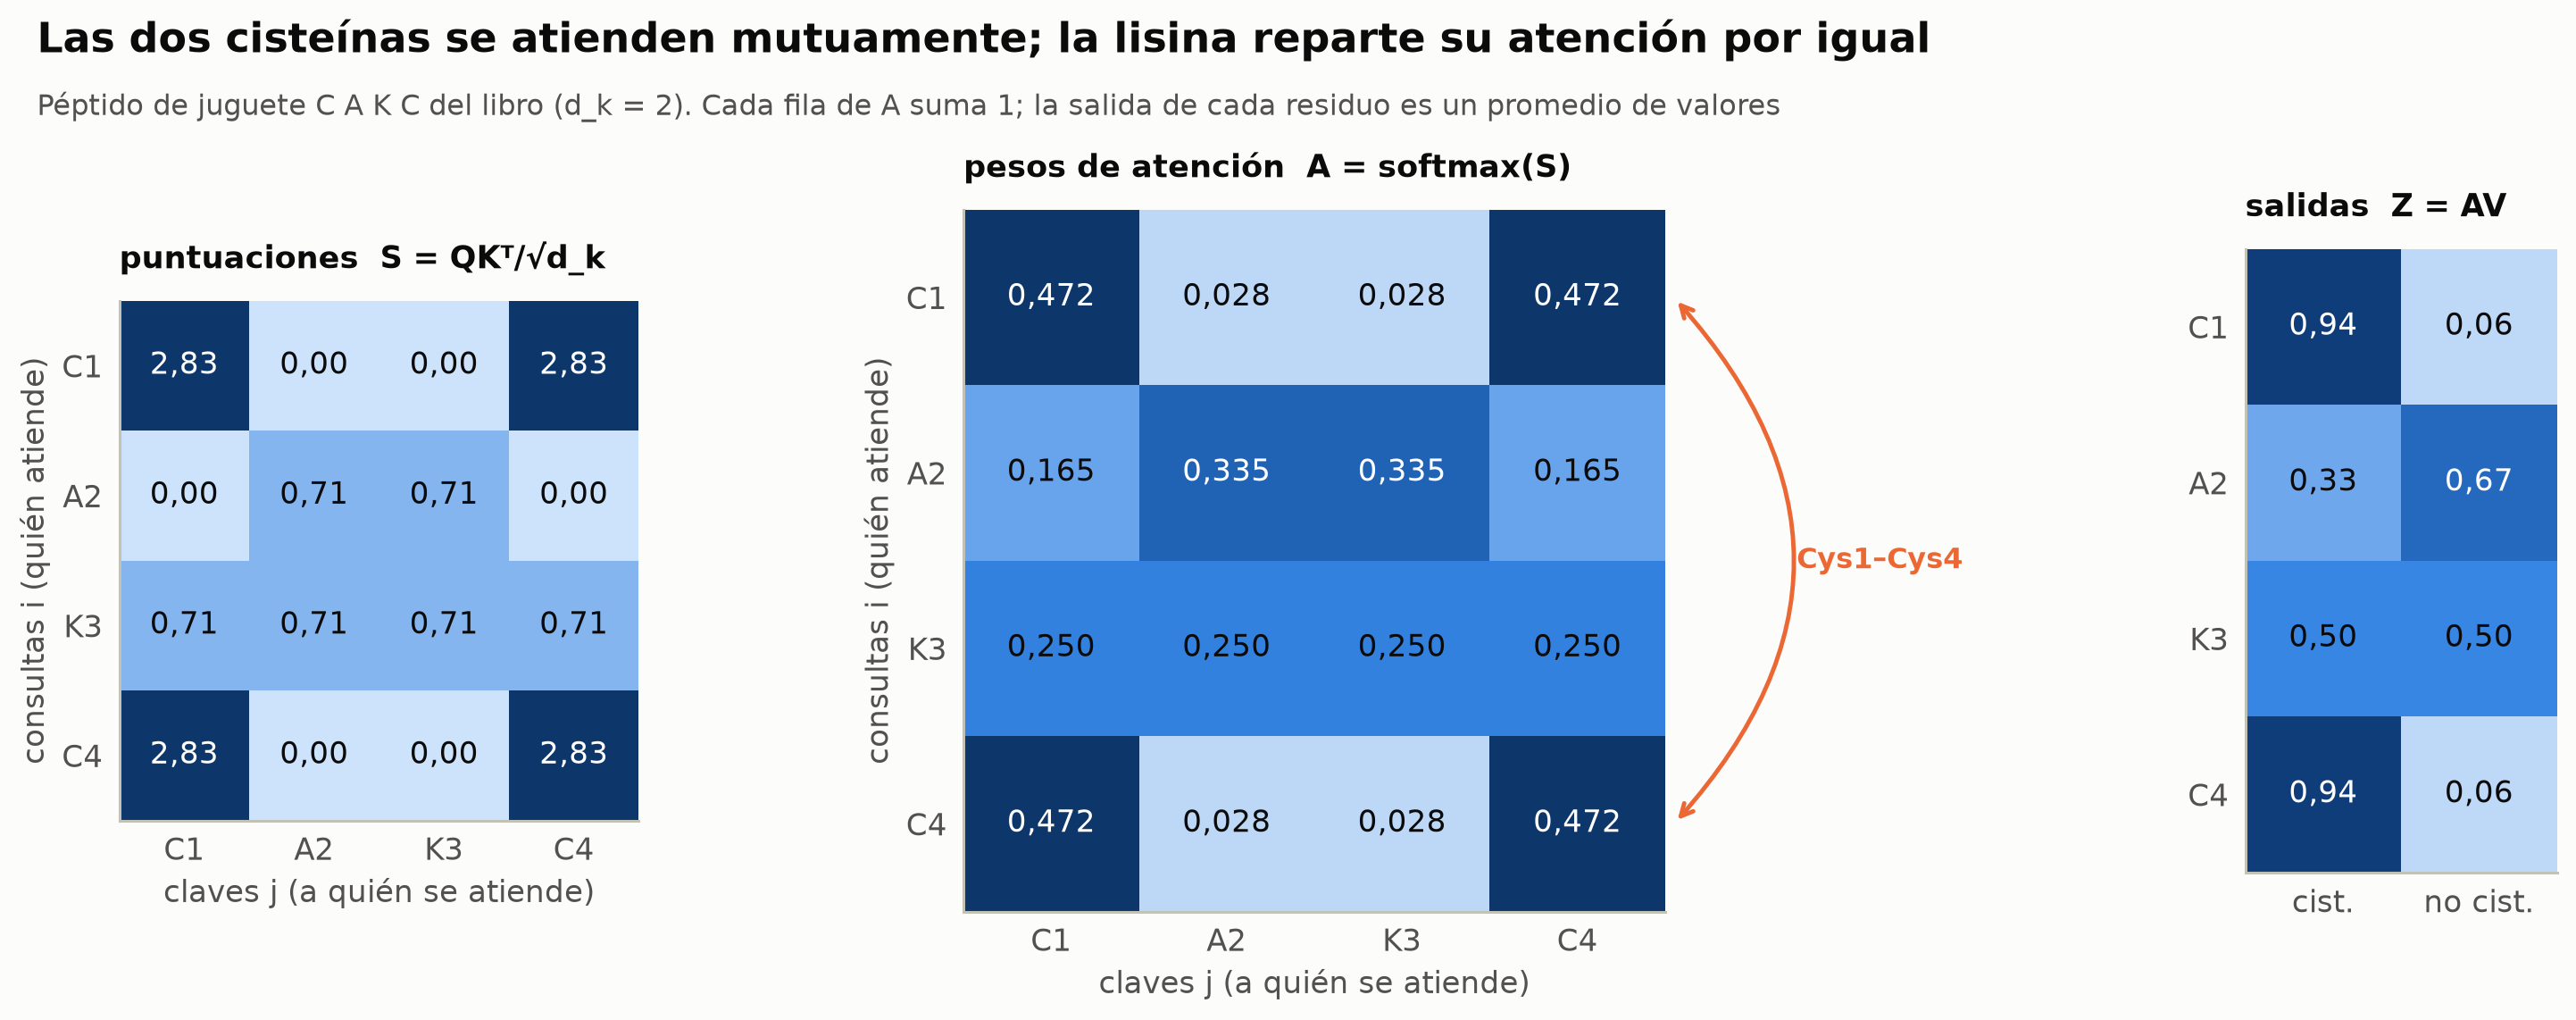

In [5]:
# Figura: el mecanismo completo sobre el péptido de juguete
fig, axs = plt.subplots(1, 3, figsize=(13, 4.4), gridspec_kw=dict(width_ratios=[1, 1.45, 0.6], wspace=0.28))
for ax, M, name, cmap, fmt in ((axs[0], S_toy, "puntuaciones  S = QKᵀ/√d_k", ec.CMAP_SEQ, "{:.2f}"),
                               (axs[1], A_toy, "pesos de atención  A = softmax(S)", ec.CMAP_SEQ, "{:.3f}")):
    im = ax.imshow(M, cmap=cmap, vmin=0, vmax=M.max())
    for i in range(4):
        for j in range(4):
            ax.text(j, i, fmt.format(M[i, j]).replace(".", ","), ha="center", va="center", fontsize=11,
                    color="white" if M[i, j] > 0.55 * M.max() else ec.INK)
    ax.set_xticks(range(4)); ax.set_xticklabels(lab, fontsize=11); ax.set_yticks(range(4)); ax.set_yticklabels(lab, fontsize=11)
    ax.set_xlabel("claves j (a quién se atiende)"); ax.set_ylabel("consultas i (quién atiende)")
    ax.set_title(name, loc="left", fontsize=11.5); ax.grid(False)
ax = axs[2]
im = ax.imshow(Z_toy, cmap=ec.CMAP_SEQ, vmin=0, vmax=1)
for i in range(4):
    for j in range(2):
        ax.text(j, i, f"{Z_toy[i, j]:.2f}".replace(".", ","), ha="center", va="center", fontsize=11,
                color="white" if Z_toy[i, j] > 0.55 else ec.INK)
ax.set_xticks([0, 1]); ax.set_xticklabels(["cist.", "no cist."]); ax.set_yticks(range(4)); ax.set_yticklabels(lab, fontsize=11)
ax.set_title("salidas  Z = AV", loc="left", fontsize=11.5); ax.grid(False)
axs[1].annotate("", xy=(3.55, 0), xytext=(3.55, 3), annotation_clip=False,
                arrowprops=dict(arrowstyle="<->", color=ec.ORANGE, lw=1.6, connectionstyle="arc3,rad=0.45"))
axs[1].text(4.25, 1.5, "Cys1–Cys4", color=ec.ORANGE, fontsize=10.5, ha="left", va="center", fontweight="bold")
ec.fig_title(fig, "Las dos cisteínas se atienden mutuamente; la lisina reparte su atención por igual",
             "Péptido de juguete C A K C del libro (d_k = 2). Cada fila de A suma 1; la salida de cada residuo es un promedio de valores")
plt.show()

En un modelo real hay **varias cabezas** de atención en paralelo, cada una con sus propias $W_Q, W_K, W_V$, que pueden
especializarse en relaciones distintas (vecinos en la secuencia, residuos en contacto, pares de cisteínas). Un **bloque
*transformer*** combina la atención de varias cabezas con una pequeña red densa aplicada a cada posición, conexiones
residuales y normalización; un modelo apila muchos bloques. Como la atención no «ve» el orden (es invariante a
permutaciones), la posición se inyecta explícitamente: ESM-2 usa **codificaciones posicionales rotatorias**. El coste es
$O(L^2)$ en tiempo y memoria, porque hay que llenar la matriz $A$ de $L\times L$; eso limita la longitud de las secuencias.

| Modelo | Capas | Cabezas por capa | $d$ | Parámetros | Uso en esta clase |
|---|---|---|---|---|---|
| ESM-2 `t6_8M` | 6 | 20 | 320 | 8 M | — |
| ESM-2 `t12_35M` | 12 | 20 | 480 | 35 M | **en vivo** (CPU) |
| ESM-2 `t33_650M` | 33 | 20 | 1280 | 650 M | cifras del libro (precalculadas) |
| ESM-2 `t36_3B` | 36 | 40 | 2560 | 3 000 M | base de ESMFold (Lin et al., 2023) |
| ESM-2 `t48_15B` | 48 | 40 | 5120 | 15 000 M | el mayor de la familia (Lin et al., 2023) |

> ✅ **Compruebe su comprensión.** (a) ¿Por qué cada fila de $A$ suma 1 pero las columnas no? (b) Si duplicamos todas las
> claves ($K\to 2K$), ¿la atención se vuelve más o menos concentrada? (c) ¿Cuántos pesos $A_{ij}$ calcula una capa de
> ESM-2 35M para la ubiquitina (incluidos los *tokens* especiales de inicio y fin)?
>
> *Respuestas:* (a) la *softmax* normaliza cada fila: es la distribución de la atención **de** $i$; (b) más concentrada:
> las puntuaciones se duplican; (c) $20 \text{ cabezas}\times78^2 = 121\,680$.

---

## 4. ¿Por qué dividir entre $\sqrt{d_k}$? Un experimento numérico

Supongamos que las componentes de $\mathbf{q}$ y $\mathbf{k}$ son independientes, con media 0 y varianza 1. Entonces el
producto escalar

$$
\mathbf{q}^\top\mathbf{k}=\sum_{m=1}^{d_k}q_m k_m
$$

es una suma de $d_k$ términos de media 0 y varianza $\mathbb{E}[q_m^2]\,\mathbb{E}[k_m^2]=1$, y por tanto tiene **varianza
$d_k$**. Con $d_k=64$ los productos escalares tendrían desviación típica 8; la *softmax* se saturaría (casi todo el peso en una
sola posición) y sus gradientes serían minúsculos. Dividir entre $\sqrt{d_k}$ devuelve la varianza a 1.

| Símbolo | Significado |
|---|---|
| $q_m,\ k_m$ | Componente $m$ de la consulta y de la clave |
| $\mathbb{E}[\cdot]$ | Esperanza (valor medio) |
| $\max_j A_{ij}$ | Peso de la posición más atendida: cerca de 1 = atención saturada |

> 🤔 **Antes de ejecutar, prediga.** Con $L=76$ posiciones y $d_k=64$, ¿qué peso recibirá en promedio la posición más
> atendida **sin** escalar? ¿Y **con** escalado?

 d_k  escalado     sd  max_peso  entropia
   2     False  1.461     0.157     3.516
   2      True  1.004     0.097     3.866
  64     False  7.985     0.782     0.599
  64      True  0.999     0.097     3.849
 256     False 15.890     0.880     0.303
 256      True  1.008     0.098     3.844


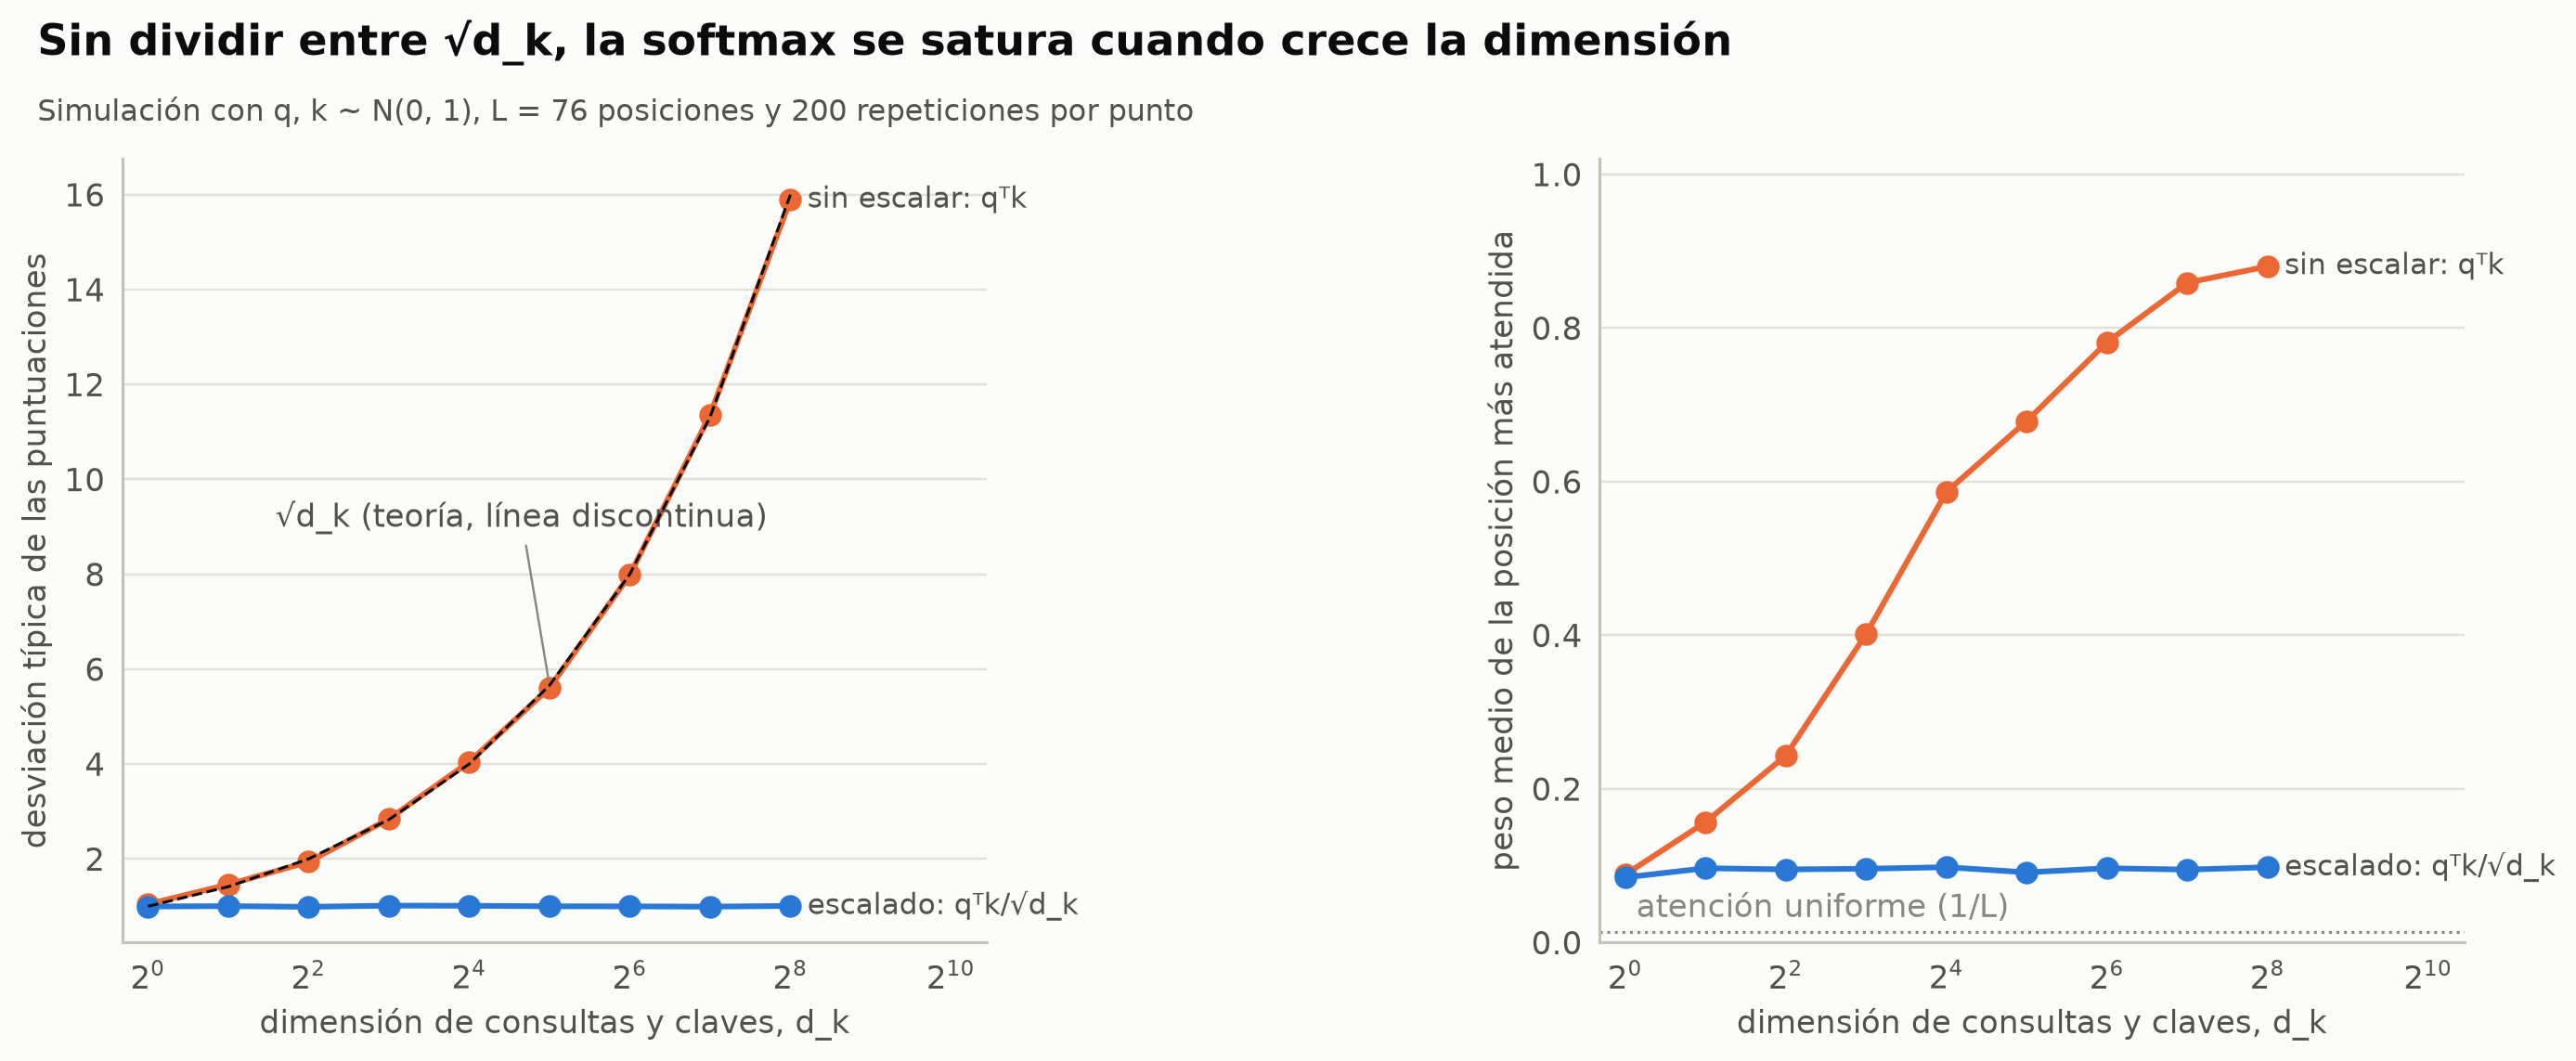

In [6]:
# Simulación: consultas y claves aleatorias N(0,1); ¿cuánto se concentra la atención al crecer d_k?
rng = np.random.default_rng(17)
dks = [1, 2, 4, 8, 16, 32, 64, 128, 256]
Lsim, n_rep = 76, 200
res = []
for dk in dks:
    for scaled in (False, True):
        q = rng.standard_normal((n_rep, dk)); k = rng.standard_normal((n_rep, Lsim, dk))
        s = np.einsum("rd,rld->rl", q, k) / (np.sqrt(dk) if scaled else 1.0)
        a = softmax_rows(s)
        res.append(dict(d_k=dk, escalado=scaled, sd=s.std(), max_peso=a.max(1).mean(),
                        entropia=(-(a * np.log(a + 1e-300)).sum(1)).mean()))
res = pd.DataFrame(res)
print(res[res.d_k.isin([2, 64, 256])].round(3).to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw=dict(wspace=0.32))
for scaled, col, name in ((False, ec.ORANGE, "sin escalar: qᵀk"), (True, ec.BLUE, "escalado: qᵀk/√d_k")):
    r = res[res.escalado == scaled]
    axs[0].plot(r.d_k, r.sd, "o-", color=col, lw=2); axs[1].plot(r.d_k, r.max_peso, "o-", color=col, lw=2)
    ec.label_end(axs[0], r.d_k.iloc[-1], r.sd.iloc[-1], name)
    ec.label_end(axs[1], r.d_k.iloc[-1], r.max_peso.iloc[-1], name)
axs[0].plot(dks, np.sqrt(dks), "--", color=ec.INK, lw=1, zorder=5)
axs[0].annotate("√d_k (teoría, línea discontinua)", (32, np.sqrt(32)), xytext=(3, 9), color=ec.INK_2,
                arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=0.8))
axs[1].axhline(1 / Lsim, color=ec.MUTED, ls=":", lw=1); axs[1].text(1.1, 1 / Lsim + 0.02, "atención uniforme (1/L)", color=ec.MUTED)
for ax in axs:
    ax.set_xscale("log", base=2); ax.set_xlabel("dimensión de consultas y claves, d_k"); ax.set_xlim(0.8, 1400)
axs[0].set_ylabel("desviación típica de las puntuaciones"); axs[1].set_ylabel("peso medio de la posición más atendida")
axs[1].set_ylim(0, 1.02)
ec.fig_title(fig, "Sin dividir entre √d_k, la softmax se satura cuando crece la dimensión",
             "Simulación con q, k ~ N(0, 1), L = 76 posiciones y 200 repeticiones por punto")
plt.show()

> 🔎 **Qué observamos.** Sin escalar, la desviación típica de las puntuaciones crece como $\sqrt{d_k}$ (≈ 8 con $d_k=64$) y la
> posición más atendida se lleva en promedio más de la mitad del peso: la atención se vuelve casi un «todo o nada» y la
> *softmax* apenas transmite gradiente. Con escalado, la desviación típica queda en 1 para cualquier $d_k$ y la atención se
> mantiene repartida. Por eso la fórmula lleva $\sqrt{d_k}$ (Vaswani et al., 2017); ESM-2 35M usa $d_k = 480/20 = 24$ por cabeza.

---

## 5. Modelado de lenguaje enmascarado y perplejidad

### 5.1 Cómo se entrena sin etiquetas

¿Cómo se entrena un modelo así si nadie ha etiquetado las proteínas? Con el juego de la sección 1. En el **modelado de
lenguaje enmascarado** (MLM), popularizado por BERT (Devlin et al., 2019), se elige al azar un 15 % de las posiciones de
cada secuencia; la mayoría se sustituye por un *token* especial `<mask>`, algunas por un aminoácido aleatorio y otras se
dejan intactas, y el modelo debe recuperar el aminoácido original a partir del contexto:

$$
\mathcal{L}_{\mathrm{MLM}}(\boldsymbol\theta) = -\,\mathbb{E}_{x\sim\mathcal{D}}\;\mathbb{E}_{M}\left[\sum_{i\in M}\log p_{\boldsymbol\theta}\big(x_i\,\big|\,x_{\setminus M}\big)\right].
$$

| Símbolo | Significado |
|---|---|
| $x\sim\mathcal{D}$ | Secuencia tomada de la base de datos de entrenamiento (p. ej., UniRef) |
| $M$ | Conjunto aleatorio de posiciones enmascaradas |
| $x_{\setminus M}$ | Secuencia con esas posiciones ocultas: el contexto visible |
| $p_{\boldsymbol\theta}(x_i\mid x_{\setminus M})$ | Distribución sobre los 20 aminoácidos que predice el modelo en la posición $i$ |
| $\boldsymbol\theta$ | Parámetros del modelo (35 millones en nuestro ESM-2 pequeño) |

Es una **entropía cruzada multiclase**, la misma pérdida de la regresión logística de la Lección 17.1 generalizada a 20
clases, y se minimiza con retropropagación (Lección 17.2). Como cualquier secuencia proporciona sus propios «problemas» de
entrenamiento, se aprovecha toda la diversidad de las bases de datos: es aprendizaje **autosupervisado**.

### 5.2 Perplejidad: cuántos aminoácidos «duda» el modelo

La calidad del modelo se resume en la **perplejidad**, la exponencial de la pérdida media por posición:

$$
\mathrm{PPL} = \exp\!\left(-\frac{1}{L}\sum_{i=1}^{L}\log p_{\boldsymbol\theta}\big(x_i\mid x_{\setminus i}\big)\right)
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{PPL}$ | Perplejidad: número efectivo de aminoácidos entre los que el modelo «duda» en cada posición. Vale 20 para un modelo que no sabe nada y 1 para uno que acierta siempre con certeza |
| $x_{\setminus i}$ | La secuencia con sólo la posición $i$ enmascarada (por eso se habla de **pseudo**perplejidad) |

**Ejemplo a mano.** Un modelo que asigna probabilidad uniforme $1/20$ a todo tiene
$\mathrm{PPL}=\exp(-\log(1/20))=20$. Si en una proteína de 3 residuos el modelo da al residuo nativo probabilidades 0,9;
0,5 y 0,1, entonces $-\tfrac13(\ln 0{,}9+\ln 0{,}5+\ln 0{,}1)=\tfrac13(0{,}105+0{,}693+2{,}303)=1{,}034$ y
$\mathrm{PPL}=e^{1{,}034}=2{,}81$: en promedio el modelo duda entre unos 2,8 aminoácidos.

### 5.3 Enmascarar la ubiquitina con ESM-2

El alfabeto de ESM tiene 33 *tokens*: los 20 aminoácidos, algunos ambiguos (X, B, Z…) y especiales (`<cls>` al inicio,
`<eos>` al final, `<mask>`). Por eso la posición $i$ de la proteína (numerada desde 1) es la columna $i$ del tensor de
*tokens*: la columna 0 la ocupa `<cls>`.

Para cada posición $i$ construimos una copia de la secuencia con `<mask>` en $i$ y leemos la distribución predicha allí.
Las 76 copias van juntas en un lote: una sola pasada del modelo.

In [7]:
AA_IDX = None if not ESM_LIVE else [alphabet.get_idx(a) for a in AA]

def tokenize(seq):
    _, _, tok = batch_converter([("p", seq)])
    return tok                                   # forma (1, L+2): <cls> seq <eos>

def masked_logp(seq):
    """log p(x_i = a | x_\\i) para cada posición i y cada aminoácido a (matriz L × 20, orden AA)."""
    tok = tokenize(seq)
    n = len(seq)
    batch = tok.repeat(n, 1)
    for i in range(n):
        batch[i, i + 1] = alphabet.mask_idx     # +1 por el token <cls>
    logits = model(batch)["logits"]             # (n, L+2, 33)
    logp = torch.log_softmax(logits, dim=-1)
    return np.array([logp[i, i + 1, AA_IDX].numpy() for i in range(n)])

t0 = time.time()
if ESM_LIVE:
    LOGP_H = masked_logp(UBQ_HUMAN)             # ubiquitina humana
    LOGP_Y = masked_logp(UBQ_YEAST)             # ubiquitina de levadura (para el experimento de la sección 9)
    print(f"Marginales enmascarados calculados en vivo en {time.time() - t0:.1f} s · "
          f"máx. diferencia con el respaldo: {np.abs(LOGP_H - CACHE35['logp20_human']).max():.1e}")
else:
    LOGP_H, LOGP_Y = CACHE35["logp20_human"].astype(float), CACHE35["logp20_yeast"].astype(float)
    print("Marginales enmascarados tomados del respaldo 35M")
LOGP_650 = BOOK650["logp20"].astype(float)        # los del libro (650M)

def pseudo_ppl(logp, seq):
    wt = [AA.index(c) for c in seq]
    return float(np.exp(-logp[np.arange(len(seq)), wt].mean()))

def entropy_rows(logp):
    p = np.exp(logp); p = p / p.sum(1, keepdims=True)
    return -(p * np.log(p)).sum(1)

print(f"Pseudo-perplejidad de la ubiquitina humana: 35M = {pseudo_ppl(LOGP_H, UBQ_HUMAN):.2f} · "
      f"650M (libro) = {pseudo_ppl(LOGP_650, UBQ_HUMAN):.3f} · modelo ignorante = 20")
for name, i in (("I44", 43), ("E24", 23)):
    for tag, lp in (("35M ", LOGP_H), ("650M", LOGP_650)):
        p = np.exp(lp[i]); o = np.argsort(-p)[:6]
        print(f"{name} {tag}: " + "  ".join(f"{AA[k]} {p[k]:.3f}" for k in o) + f"   (entropía {entropy_rows(lp)[i]:.2f} nats)")

Marginales enmascarados calculados en vivo en 1.9 s · máx. diferencia con el respaldo: 0.0e+00
Pseudo-perplejidad de la ubiquitina humana: 35M = 4.31 · 650M (libro) = 1.783 · modelo ignorante = 20
I44 35M : I 0.660  L 0.182  V 0.093  M 0.025  F 0.014  T 0.006   (entropía 1.11 nats)
I44 650M: I 0.993  V 0.006  L 0.000  T 0.000  A 0.000  F 0.000   (entropía 0.05 nats)
E24 35M : E 0.197  L 0.194  A 0.163  Q 0.107  S 0.073  K 0.056   (entropía 2.32 nats)
E24 650M: A 0.387  N 0.117  S 0.100  L 0.095  Q 0.058  G 0.043   (entropía 2.11 nats)


> 🔎 **Qué observamos.** Con el modelo del libro (650M), en la Ile44 del parche hidrofóbico el nativo recibe **0,993** y casi
> todo lo demás va a Val (0,006), otro hidrofóbico ramificado. En el Glu24, expuesto al solvente, la distribución es amplia
> (entropía ≈ 2,1 nats) y el nativo recibe sólo **0,027**; la alanina se lleva 0,387. Son las cifras del libro. El modelo
> pequeño cuenta la misma historia con menos convicción: en I44 da 0,66 al nativo y reparte el resto entre Leu y Val (todos
> hidrofóbicos alifáticos), y en E24 duda entre E, L y A. Su pseudo-perplejidad (≈ 4,3) es mayor que la del grande (1,78),
> pero muy lejos de 20: incluso 35 M de parámetros bastan para aprender buena parte de la «gramática» de la ubiquitina.

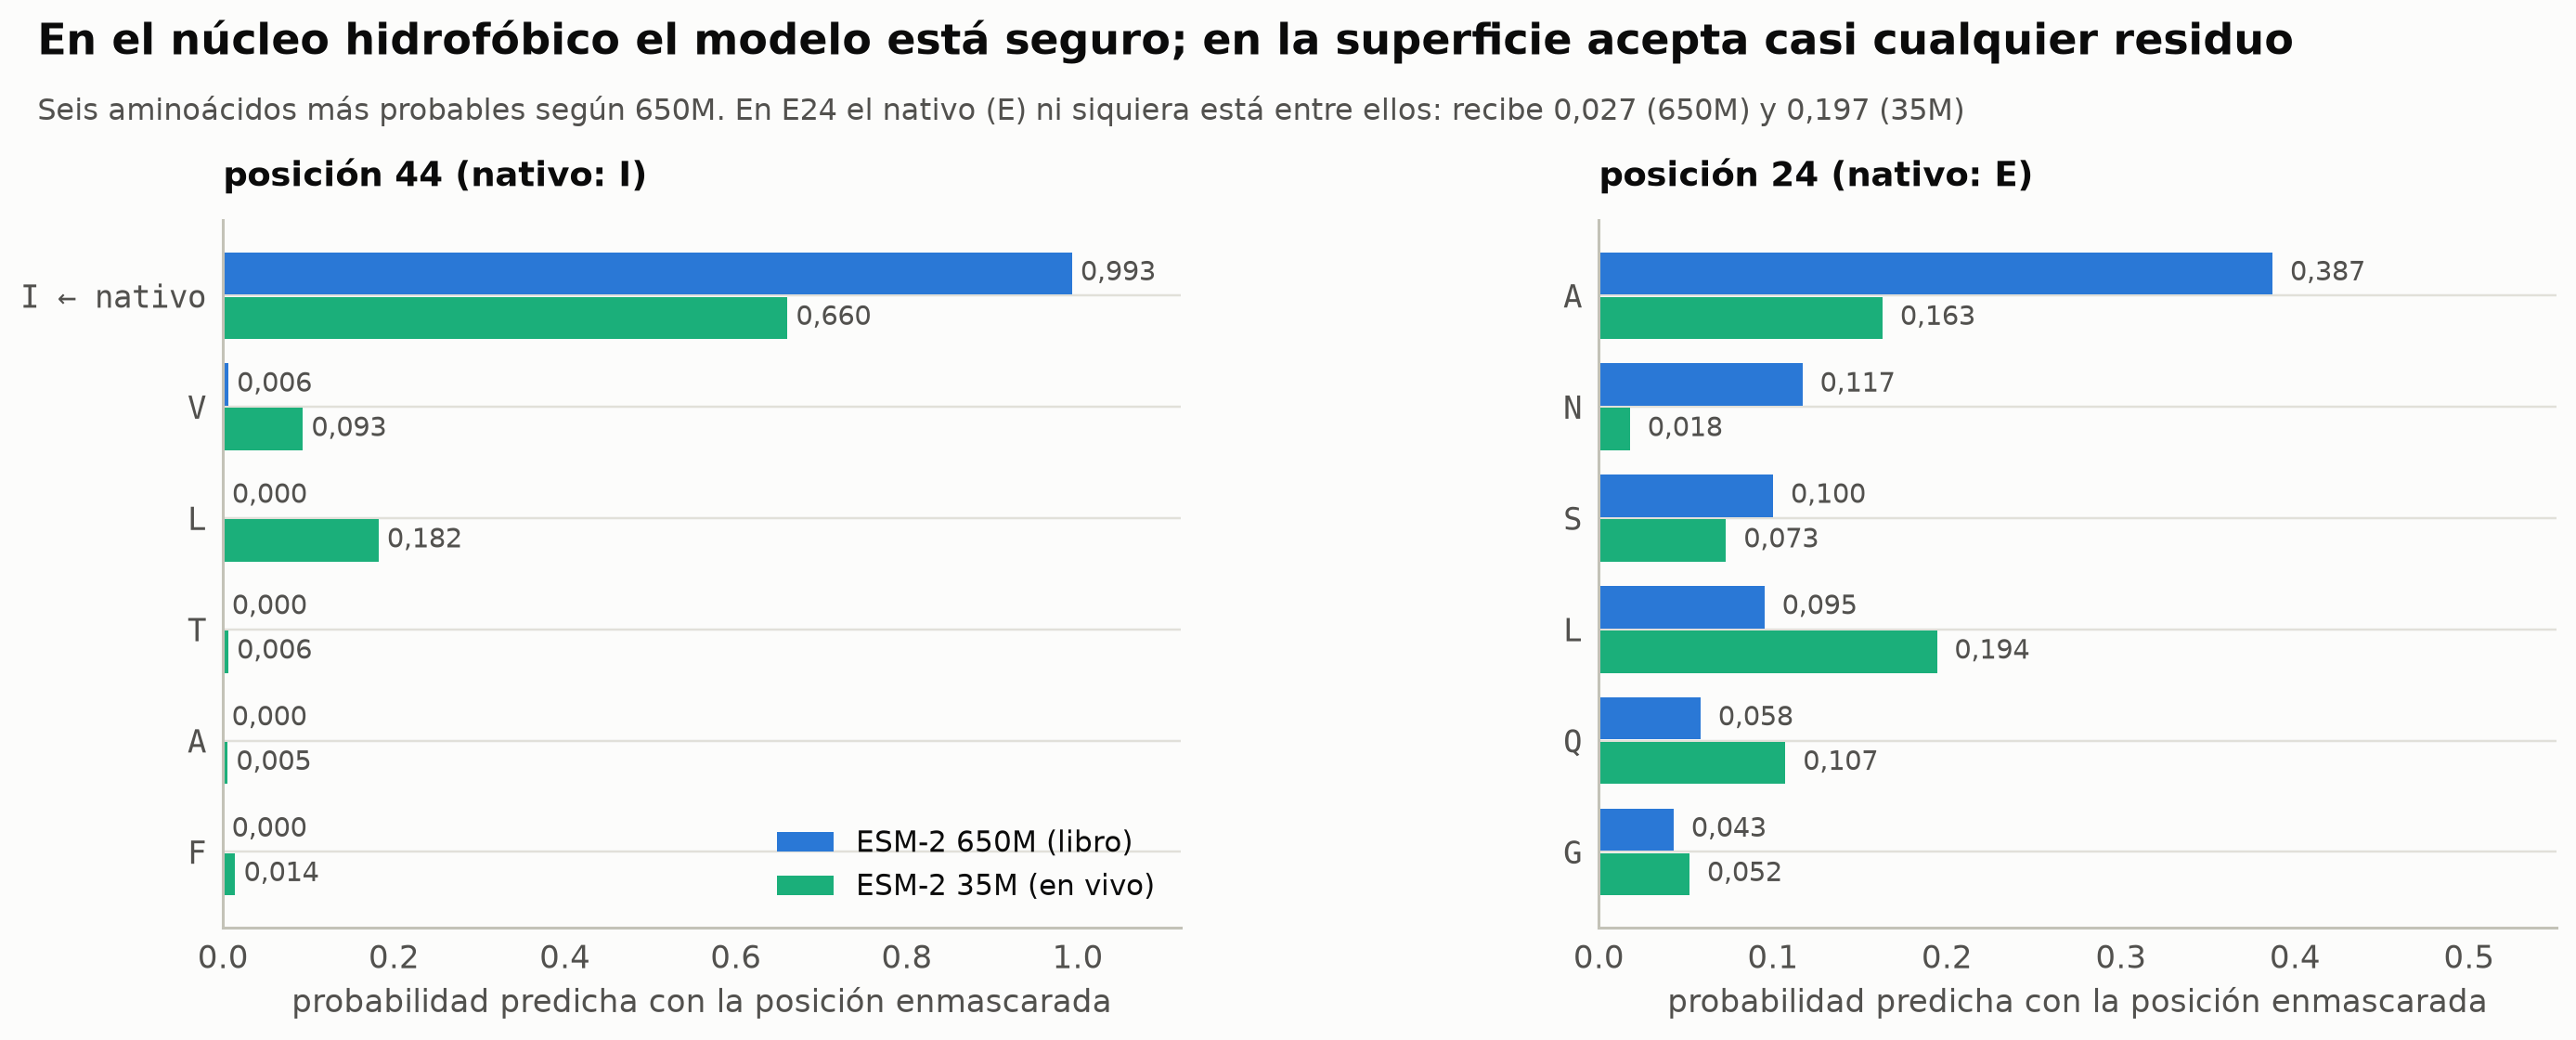

In [8]:
# Figura: las distribuciones predichas en I44 y E24 (réplica de la figura del libro, con ambos modelos)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw=dict(wspace=0.3))
for ax, (name, i, nat) in zip(axs, (("posición 44 (nativo: I)", 43, "I"), ("posición 24 (nativo: E)", 23, "E"))):
    p650 = np.exp(LOGP_650[i]); p35 = np.exp(LOGP_H[i])
    order = np.argsort(-p650)[:6]
    y = np.arange(6)
    ax.barh(y - 0.2, p650[order], height=0.38, color=ec.BLUE, label="ESM-2 650M (libro)")
    ax.barh(y + 0.2, p35[order], height=0.38, color=ec.AQUA, label="ESM-2 35M (en vivo)")
    for k, o in enumerate(order):
        ax.text(p650[o] + 0.01, k - 0.2, f"{p650[o]:.3f}".replace(".", ","), va="center", fontsize=9.5, color=ec.INK_2)
        ax.text(p35[o] + 0.01, k + 0.2, f"{p35[o]:.3f}".replace(".", ","), va="center", fontsize=9.5, color=ec.INK_2)
    ax.set_yticks(y); ax.set_yticklabels([AA[o] + (" ← nativo" if AA[o] == nat else "") for o in order],
                                         family="monospace", fontsize=11)
    ax.invert_yaxis(); ax.set_xlim(0, 1.12 if nat == "I" else 0.55)
    ax.set_xlabel("probabilidad predicha con la posición enmascarada"); ax.set_title(name, loc="left", fontsize=12)
axs[0].legend(loc="lower right", frameon=False)
ec.fig_title(fig, "En el núcleo hidrofóbico el modelo está seguro; en la superficie acepta casi cualquier residuo",
             "Seis aminoácidos más probables según 650M. En E24 el nativo (E) ni siquiera está entre ellos: recibe 0,027 (650M) y 0,197 (35M)")
plt.show()

### 5.4 🎬 Animación: el modelo recorre la ubiquitina con la máscara

En la animación, la máscara (naranja) avanza por la ubiquitina. Arriba se va dibujando la probabilidad que el modelo
pequeño asigna al residuo nativo en cada posición; abajo, las seis opciones más probables en la posición enmascarada. La
pseudo-perplejidad se acumula al final.

![La máscara recorre la ubiquitina: ESM-2 35M adivina cada residuo a partir del resto](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.3_mascara.gif)

*La máscara recorre la ubiquitina: ESM-2 35M adivina cada residuo a partir del resto*

In [9]:
p_nat = np.exp(LOGP_H[np.arange(L), [AA.index(c) for c in UBQ_HUMAN]])
frames_pos = list(range(0, L, 2)) + [L - 1]
fig = plt.figure(figsize=(12, 5.6))
ax1 = fig.add_axes([0.06, 0.52, 0.9, 0.33]); ax2 = fig.add_axes([0.06, 0.08, 0.42, 0.3]); ax3 = fig.add_axes([0.56, 0.08, 0.4, 0.3])
def update(f):
    i = frames_pos[f]
    for ax in (ax1, ax2, ax3):
        ax.clear()
    cols = [ec.BLUE if j < i else ec.GRID for j in range(L)]
    ax1.bar(np.arange(L), np.where(np.arange(L) < i, p_nat, 0), color=cols, width=0.85)
    ax1.bar([i], [1.0], color=ec.ORANGE, alpha=0.25, width=0.9)
    ax1.text(i, 1.04, "<mask>", ha="center", color=ec.ORANGE, fontsize=10, fontweight="bold")
    ax1.set_xticks(range(L)); ax1.set_xticklabels(list(UBQ_HUMAN), fontsize=6.5, family="monospace")
    ax1.get_xticklabels()[i].set_color(ec.ORANGE)
    ax1.set_ylim(0, 1.15); ax1.set_xlim(-1, L); ax1.set_ylabel("p(nativo)"); ax1.grid(axis="x", visible=False)
    p = np.exp(LOGP_H[i]); o = np.argsort(-p)[:6]
    ax2.barh(range(6), p[o], color=[ec.ORANGE if AA[k] == UBQ_HUMAN[i] else ec.AQUA for k in o])
    ax2.set_yticks(range(6)); ax2.set_yticklabels([AA[k] for k in o], family="monospace", fontsize=11); ax2.invert_yaxis()
    ax2.set_xlim(0, 1); ax2.set_title(f"posición {i+1} (nativo {UBQ_HUMAN[i]}): 6 opciones más probables", loc="left", fontsize=11)
    ax3.axis("off")
    ppl_i = np.exp(-np.log(p_nat[:i + 1]).mean())
    ax3.text(0, 0.8, f"residuos leídos: {i+1} de {L}", fontsize=12, color=ec.INK)
    ax3.text(0, 0.5, f"pseudo-perplejidad acumulada: {ppl_i:.2f}".replace(".", ","), fontsize=12, color=ec.INK)
    ax3.text(0, 0.2, "modelo ignorante: 20 · ESM-2 650M: 1,78", fontsize=11, color=ec.INK_2)
    fig.suptitle("ESM-2 35M adivina cada residuo oculto de la ubiquitina a partir del resto de la secuencia",
                 x=0.06, ha="left", y=0.98, fontsize=13, fontweight="bold")
    return []
ec.animate(fig, update, frames=len(frames_pos), interval=200, name="17.3_mascara")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

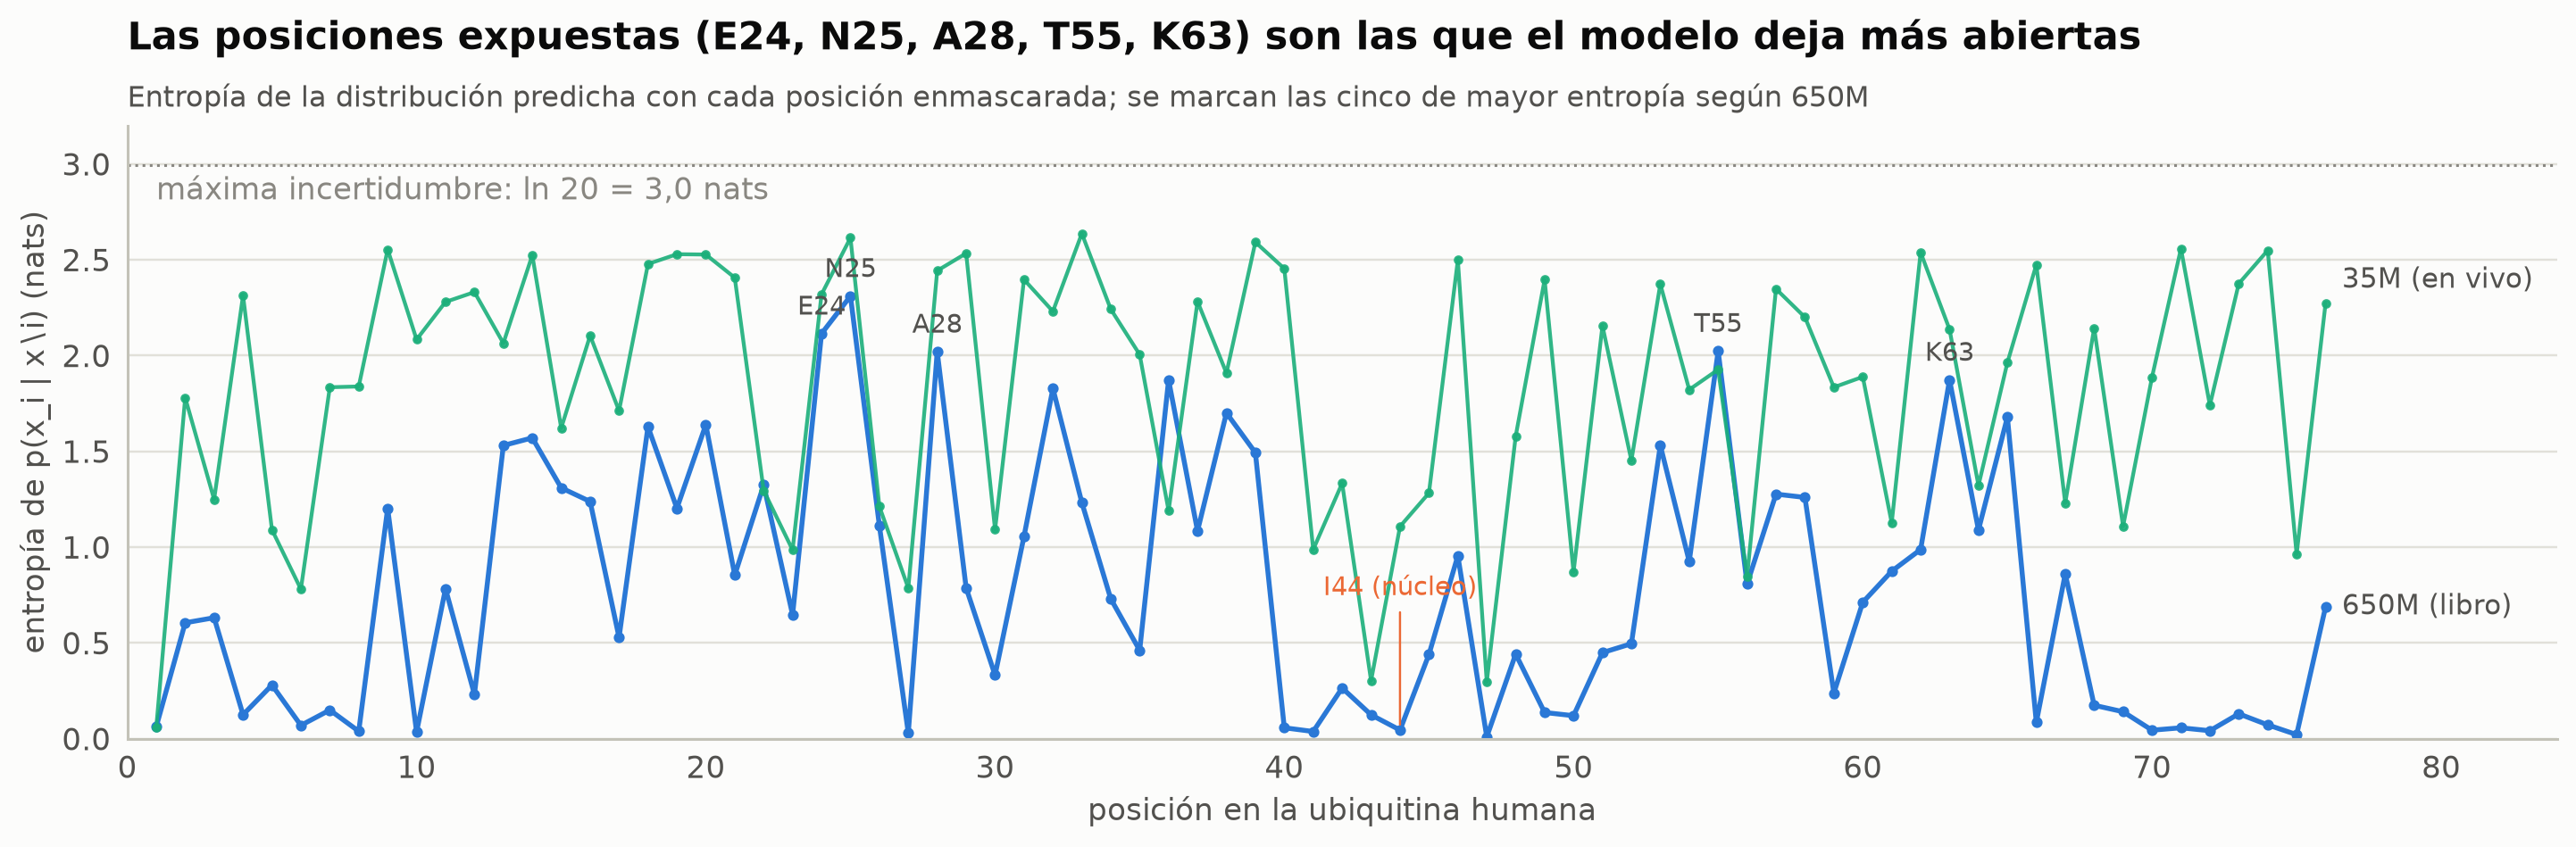

In [10]:
# Figura: perfil de incertidumbre por posición (entropía) en ambos modelos
H35, H650 = entropy_rows(LOGP_H), entropy_rows(LOGP_650)
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(np.arange(1, L + 1), H650, color=ec.BLUE, lw=1.8, marker="o", ms=3)
ax.plot(np.arange(1, L + 1), H35, color=ec.AQUA, lw=1.4, marker="o", ms=2.5, alpha=0.9)
ec.label_end(ax, L, H650[-1], "650M (libro)"); ec.label_end(ax, L, H35[-1] + 0.12, "35M (en vivo)")
for i in np.argsort(H650)[-5:]:
    ax.annotate(f"{UBQ_HUMAN[i]}{i+1}", (i + 1, H650[i]), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9.5, color=ec.INK_2)
ax.annotate("I44 (núcleo)", (44, H650[43]), xytext=(44, 0.75), ha="center", fontsize=9.5, color=ec.ORANGE,
            arrowprops=dict(arrowstyle="-", color=ec.ORANGE, lw=0.8))
ax.axhline(np.log(20), color=ec.MUTED, ls=":", lw=1); ax.text(1, np.log(20) - 0.18, "máxima incertidumbre: ln 20 = 3,0 nats", color=ec.MUTED)
ax.set_xlim(0, L + 8); ax.set_ylim(0, 3.2); ax.set_xlabel("posición en la ubiquitina humana"); ax.set_ylabel("entropía de p(x_i | x∖i) (nats)")
ec.title(ax, "Las posiciones expuestas (E24, N25, A28, T55, K63) son las que el modelo deja más abiertas",
         "Entropía de la distribución predicha con cada posición enmascarada; se marcan las cinco de mayor entropía según 650M")
plt.show()

> 🔎 **Qué observamos.** Las cinco posiciones de mayor entropía según 650M son **K63, A28, T55, E24 y N25**, las mismas que
> lista el libro, y todas están en la superficie de la proteína. Los dos modelos coinciden en la forma del perfil: el
> pequeño es más «dudoso» en casi todas partes, pero las posiciones que ambos dejan abiertas son las mismas.
>
> ✅ **Compruebe su comprensión.** ¿Por qué la pseudo-perplejidad no es una perplejidad «de verdad»? *Respuesta:* porque
> cada término condiciona en **todo** el resto de la secuencia ($x_{\setminus i}$), incluidas las posiciones posteriores;
> el producto de esas condicionales no es la probabilidad conjunta de la secuencia.

---

## 6. Qué aprende el modelo (I): contactos a partir de la atención

### 6.1 La idea

Si dos residuos están en contacto, sus mutaciones están **correlacionadas** a lo largo de la evolución: cuando uno cambia de
pequeño a grande, el otro suele cambiar de grande a pequeño para que la proteína siga cabiendo en su forma (coevolución,
Lección 15.2). Un modelo que predice bien los huecos tiene que haber capturado esas correlaciones: para adivinar el residuo
44 le conviene «mirar» a los residuos que lo tocan. Por eso **los mapas de atención de ESM-2 contienen información sobre los
contactos**; una regresión logística sobre ellos basta para predecir el mapa de contactos (Lin et al., 2023). `fair-esm`
incluye esa regresión ya entrenada: basta pedir `return_contacts=True`.

### 6.2 Cómo se evalúa (convenciones del libro)

* **Contacto real**: distancia entre los Cβ (Cα para la glicina) menor de 8 Å en la estructura 1UBQ.
* Sólo cuentan pares separados en la secuencia por $|i-j|\ge 6$ (los vecinos cercanos son triviales).
* **Precisión top-$L$**: de los $L=76$ pares con mayor probabilidad predicha, ¿qué fracción son contactos reales? También
  top-$L/2$ con $|i-j|\ge 12$ y top-$L/5$ con $|i-j|\ge 24$ (contactos de largo alcance, los más difíciles y útiles).

**Ejemplo a mano.** Si de los 5 pares mejor puntuados 4 son contactos reales, la precisión top-5 es $4/5 = 0{,}8$. Con
139 contactos reales entre los $\sum_{i=1}^{70}(71-i)=2\,485$ pares con $|i-j|\ge6$, un predictor al azar
acertaría sólo ≈ 5,6 % de las veces.

> 🤔 **Antes de ejecutar, prediga.** El libro obtiene con 650M una precisión top-$L$ de 0,87. ¿Cuánto espera con un modelo
> 19 veces más pequeño: 0,85, 0,65 o 0,30?

In [11]:
# Mapas de atención y contactos de ESM-2 35M para la ubiquitina humana
if ESM_LIVE:
    out = model(tokenize(UBQ_HUMAN), repr_layers=[model.num_layers], need_head_weights=True, return_contacts=True)
    ATTN = out["attentions"][0, :, :, 1:-1, 1:-1].numpy()      # capas × cabezas × L × L (sin <cls>, <eos>)
    CONTACTS_35 = out["contacts"][0].numpy()
else:
    ATTN = CACHE35["attn"].astype(float)[:, :, 1:-1, 1:-1]
    CONTACTS_35 = CACHE35["contacts"].astype(float)
CONTACTS_650 = BOOK650["contacts"].astype(float)
n_layers, n_heads = ATTN.shape[:2]
print("atención:", ATTN.shape, "· contactos:", CONTACTS_35.shape)

def precision_top(C, min_sep, frac):
    """Precisión de los int(L·frac) pares mejor puntuados con |i−j| ≥ min_sep (definición del libro)."""
    iu = np.array([(i, j) for i in range(L) for j in range(i + min_sep, L)])
    sc = C[iu[:, 0], iu[:, 1]]
    k = max(1, int(L * frac))
    top = iu[np.argsort(-sc)[:k]]
    return float(TRUE_CONTACT[top[:, 0], top[:, 1]].mean())

iu6 = np.array([(i, j) for i in range(L) for j in range(i + 6, L)])
base_rate = TRUE_CONTACT[iu6[:, 0], iu6[:, 1]].mean()
tab = pd.DataFrame({m: {"top-L (|i−j| ≥ 6)": precision_top(C, 6, 1.0),
                        "top-L/2 (|i−j| ≥ 12)": precision_top(C, 12, 0.5),
                        "top-L/5 (|i−j| ≥ 24)": precision_top(C, 24, 0.2)}
                    for m, C in (("ESM-2 35M (en vivo)", CONTACTS_35), ("ESM-2 650M (libro)", CONTACTS_650))})
tab["azar"] = base_rate
print(f"Pares con |i−j| ≥ 6: {len(iu6)} · contactos reales: {TRUE_CONTACT[iu6[:, 0], iu6[:, 1]].sum()} ({base_rate:.1%})")
tab.round(3)

atención: (12, 20, 76, 76) · contactos: (76, 76)
Pares con |i−j| ≥ 6: 2485 · contactos reales: 139 (5.6%)


,ESM-2 35M (en vivo),ESM-2 650M (libro),azar
top-L (|i−j| ≥ 6),0.658,0.868,0.056
top-L/2 (|i−j| ≥ 12),0.711,0.895,0.056
top-L/5 (|i−j| ≥ 24),0.733,1.000,0.056


> 🔎 **Qué observamos (tabla y figura siguiente).** El modelo del libro reproduce sus cifras: **0,868** en top-$L$, 0,895 en top-$L/2$ de largo alcance y
> **1,0** en los 15 pares más probables separados por 24 o más residuos. El modelo pequeño acierta ≈ 2 de cada 3 (0,66–0,73),
> doce veces mejor que el azar (5,6 %) pero claramente peor que el grande: la información estructural **emerge al escalar**
> el modelo (Lin et al., 2023). Todo esto sin alineamiento múltiple ni estructura: a partir de una única secuencia.

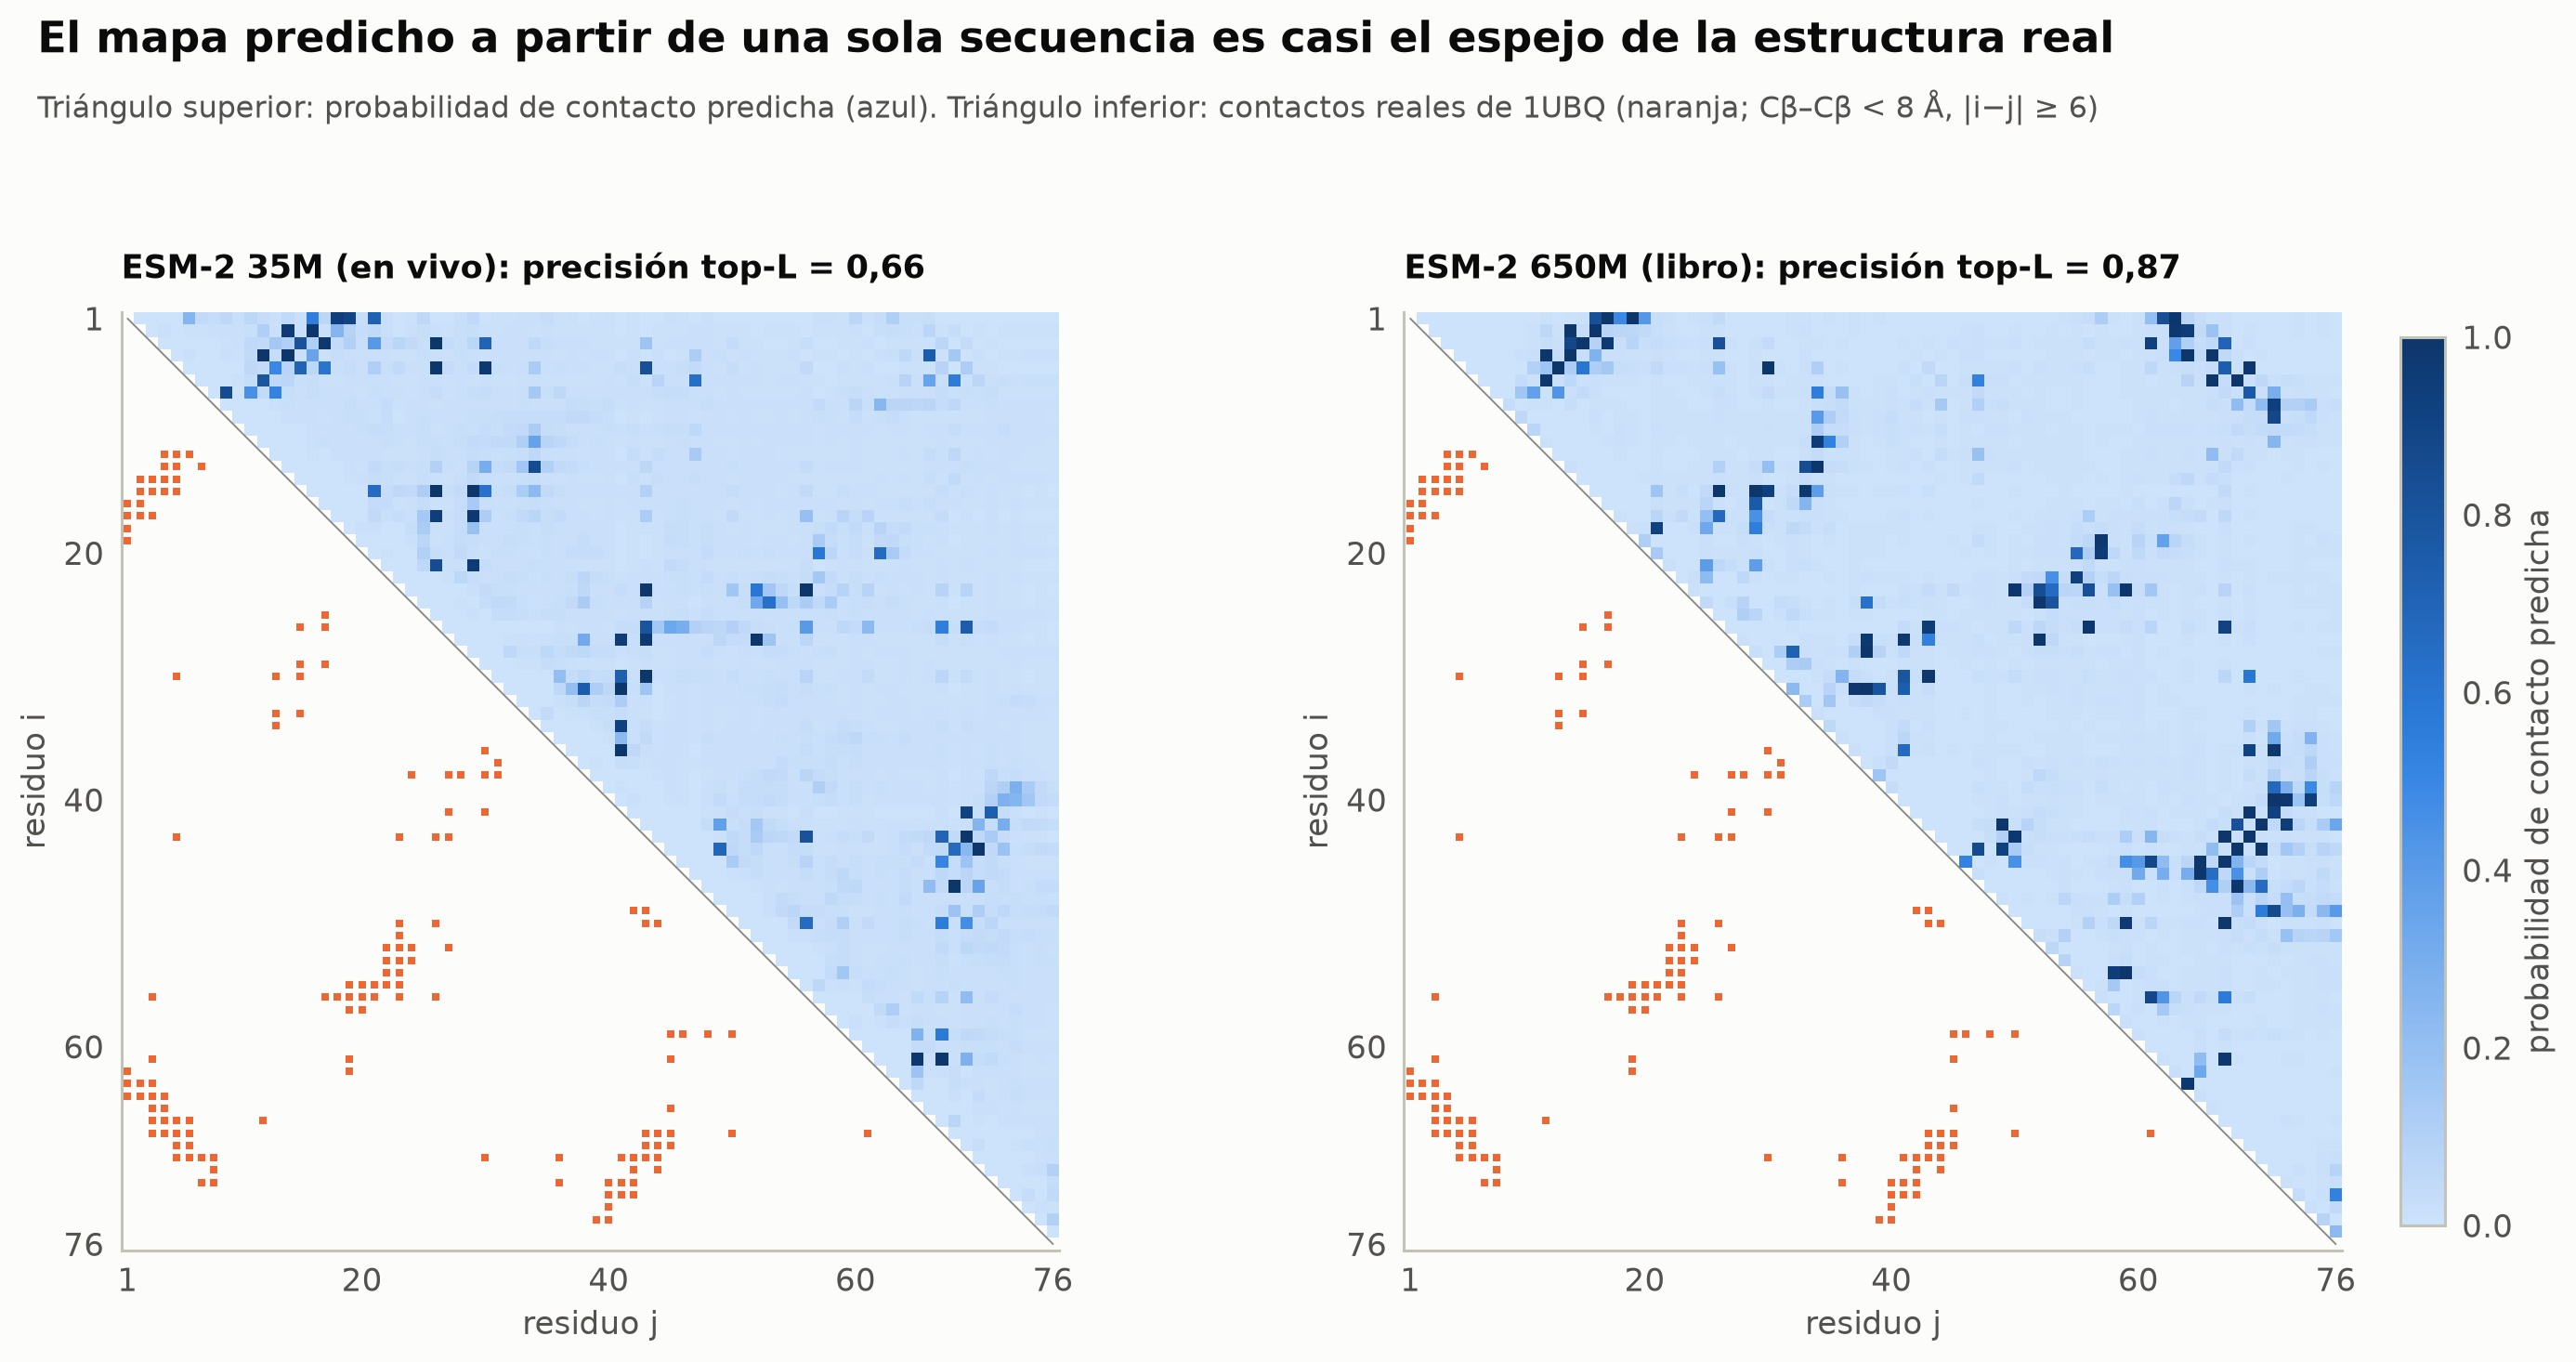

In [12]:
# Figura: mapas de contactos predichos (triángulo superior) frente a los reales de 1UBQ (triángulo inferior)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 6.2), gridspec_kw=dict(wspace=0.18))
ii, jj = np.where(np.tril(TRUE_CONTACT, -6))
for ax, C, name in ((axs[0], CONTACTS_35, "ESM-2 35M (en vivo)"), (axs[1], CONTACTS_650, "ESM-2 650M (libro)")):
    M = np.full((L, L), np.nan); iu = np.triu_indices(L, 1); M[iu] = C[iu]
    im = ax.imshow(M, cmap=ec.CMAP_SEQ, vmin=0, vmax=1, interpolation="nearest")
    ax.scatter(jj, ii, s=7, color=ec.ORANGE, marker="s", lw=0)
    ax.plot([0, L - 1], [0, L - 1], color=ec.MUTED, lw=0.6)
    tk = [0, 19, 39, 59, 75]
    ax.set_xticks(tk); ax.set_xticklabels([t + 1 for t in tk]); ax.set_yticks(tk); ax.set_yticklabels([t + 1 for t in tk])
    ax.set_xlabel("residuo j"); ax.set_ylabel("residuo i"); ax.grid(False)
    ax.set_title(f"{name}: precisión top-L = {precision_top(C, 6, 1.0):.2f}".replace(".", ","), loc="left", fontsize=11.5)
cb = fig.colorbar(im, ax=axs, fraction=0.02, pad=0.02); cb.set_label("probabilidad de contacto predicha")
ec.fig_title(fig, "El mapa predicho a partir de una sola secuencia es casi el espejo de la estructura real",
             "Triángulo superior: probabilidad de contacto predicha (azul). Triángulo inferior: contactos reales de 1UBQ (naranja; Cβ–Cβ < 8 Å, |i−j| ≥ 6)")
plt.show()

### 6.3 📊 Interactivo: ¿qué mira una cabeza de atención?

Buscamos, entre las $12\times20=240$ cabezas de ESM-2 35M, la que mejor coincide **por sí sola** con los contactos (la
precisión top-$L$ de su mapa simetrizado $\tfrac12(A+A^\top)$). Pase el cursor por el mapa: verá cuánto atiende el residuo
$i$ al $j$, la distancia real entre ambos en 1UBQ y si forman contacto.

Mejor cabeza: capa 12, cabeza 14 · precisión top-L = 0.66
Mejor cabeza por capa: 0.18 0.20 0.20 0.22 0.21 0.20 0.18 0.16 0.24 0.20 0.32 0.66


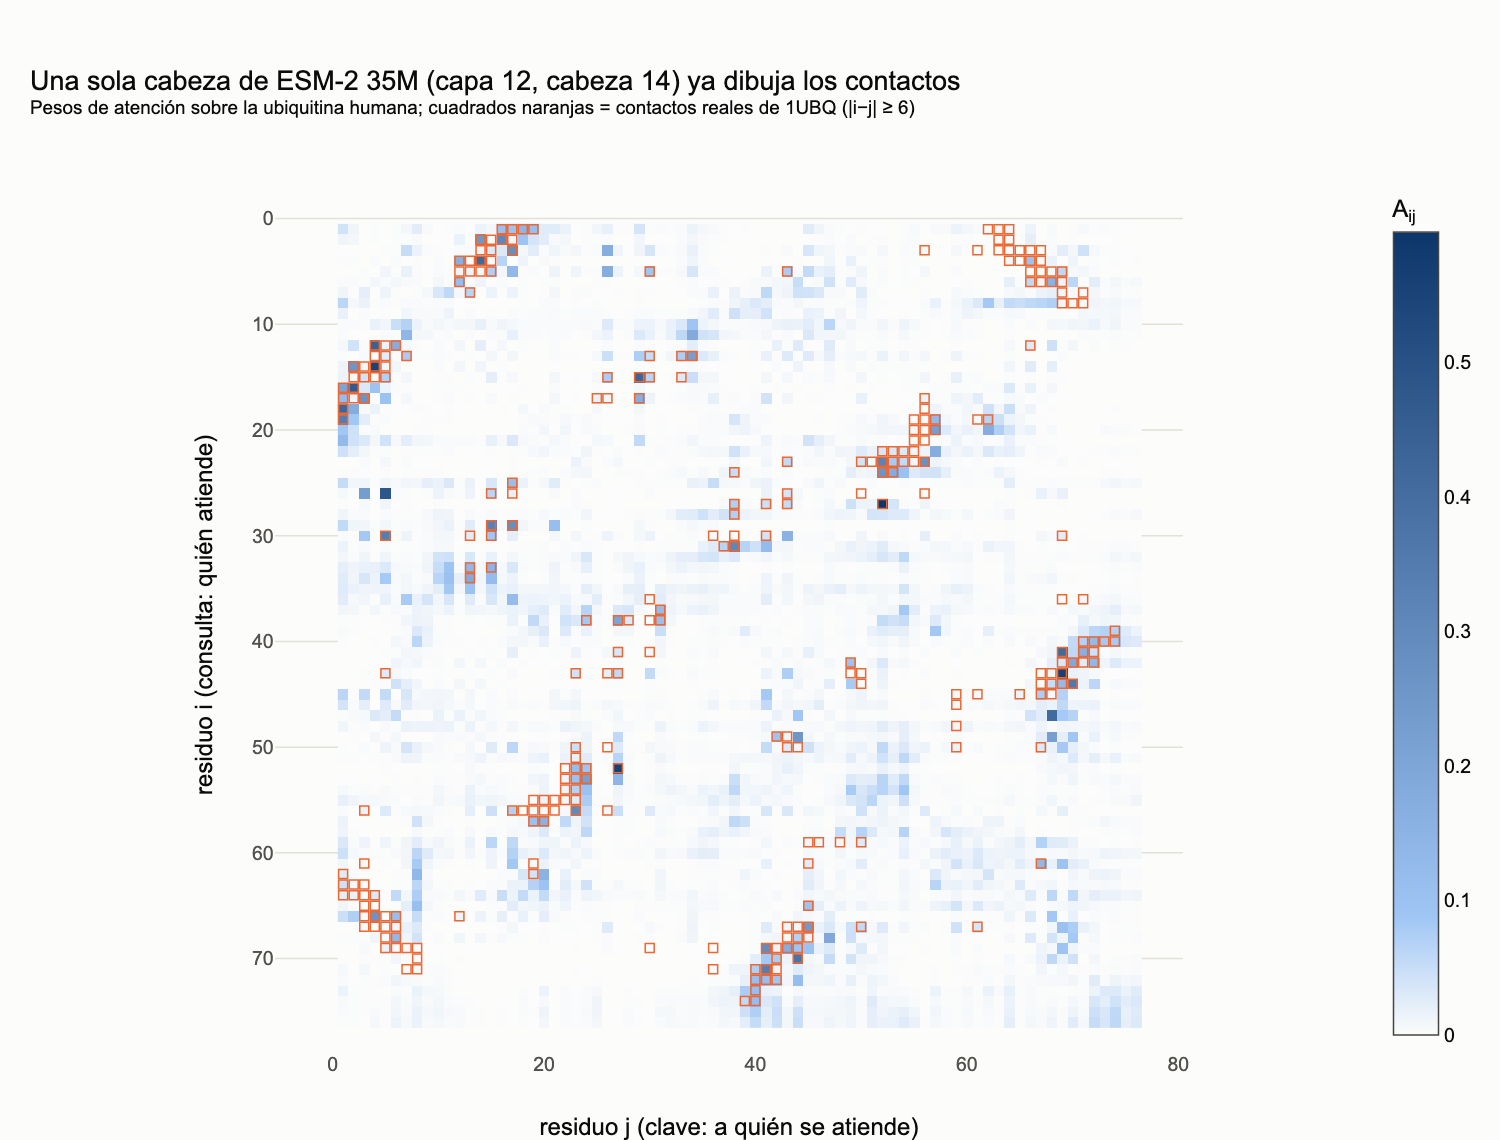

In [13]:
# Precisión top-L de cada cabeza (mapa simetrizado)
head_prec = np.zeros((n_layers, n_heads))
for l in range(n_layers):
    for h in range(n_heads):
        Ah = ATTN[l, h]
        head_prec[l, h] = precision_top((Ah + Ah.T) / 2, 6, 1.0)
bl, bh = np.unravel_index(head_prec.argmax(), head_prec.shape)
print(f"Mejor cabeza: capa {bl+1}, cabeza {bh+1} · precisión top-L = {head_prec[bl, bh]:.2f}")
print("Mejor cabeza por capa:", " ".join(f"{p:.2f}" for p in head_prec.max(1)))

A_best = ATTN[bl, bh]
hover = [[f"<b>{UBQ_HUMAN[i]}{i+1}</b> atiende a <b>{UBQ_HUMAN[j]}{j+1}</b><br>peso A<sub>ij</sub> = {A_best[i, j]:.3f}"
          f"<br>distancia Cβ–Cβ en 1UBQ: {DIST[i, j]:.1f} Å<br>|i−j| = {abs(i-j)} · "
          + ("✅ contacto real" if (TRUE_CONTACT[i, j] and abs(i - j) >= 6) else ("vecinos en la secuencia" if abs(i - j) < 6 else "sin contacto"))
          for j in range(L)] for i in range(L)]
figA = go.Figure(go.Heatmap(z=A_best, x=np.arange(1, L + 1), y=np.arange(1, L + 1), text=hover,
                            hovertemplate="%{text}<extra></extra>", colorscale=[[0, "#fcfcfb"], [0.15, "#9ec5f4"], [1, "#0d366b"]],
                            zmax=np.quantile(A_best, 0.995), colorbar=dict(title="A<sub>ij</sub>")))
ci, cj = np.where(np.triu(TRUE_CONTACT, 6))
figA.add_trace(go.Scatter(x=np.r_[cj, ci] + 1, y=np.r_[ci, cj] + 1, mode="markers", name="contacto real (1UBQ)",
                          marker=dict(symbol="square-open", size=6, color="#eb6834", line=dict(width=1)),
                          hovertemplate="contacto real %{y}–%{x}<extra></extra>"))
figA.update_layout(width=780, height=760, margin=dict(l=70, r=30, t=120, b=60),
                   title=f"Una sola cabeza de ESM-2 35M (capa {bl+1}, cabeza {bh+1}) ya dibuja los contactos"
                         f"<br><sup>Pesos de atención sobre la ubiquitina humana; cuadrados naranjas = contactos reales de 1UBQ (|i−j| ≥ 6)</sup>",
                   xaxis=dict(title="residuo j (clave: a quién se atiende)", constrain="domain"),
                   yaxis=dict(title="residuo i (consulta: quién atiende)", autorange="reversed", scaleanchor="x"),
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
figA.show()

> 🔎 **Qué observamos.** La mejor cabeza está en la **última capa** y, sola, ya acierta una buena fracción de los contactos
> top-$L$. Sus pesos altos caen sobre los cuadrados naranjas: los pares de hebras de la lámina β y la horquilla inicial.
> Las capas iniciales tienen cabezas que atienden sobre todo a vecinos de la secuencia (precisión baja, ≈ 0,2, con
> $|i-j|\ge 6$); la información de contactos aparece en las capas profundas. Una cabeza que coincide con los contactos
> **no demuestra** que el modelo «entienda» la física del plegamiento: indica dónde mira, no por qué.

### 6.4 🎬 Animación: aceptar pares de la lista, de más a menos probable

Ordenamos los pares con $|i-j|\ge 6$ por probabilidad predicha y los vamos aceptando. Verde = contacto real; rojo = falso
positivo. A la derecha, la precisión acumulada de ambos modelos.

![Aceptando pares de la lista de ESM-2: la confianza está en la cabeza de la lista](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.3_contactos.gif)

*Aceptando pares de la lista de ESM-2: la confianza está en la cabeza de la lista*

In [14]:
sc35 = CONTACTS_35[iu6[:, 0], iu6[:, 1]]; sc650 = CONTACTS_650[iu6[:, 0], iu6[:, 1]]
o35, o650 = np.argsort(-sc35), np.argsort(-sc650)
ok = TRUE_CONTACT[iu6[:, 0], iu6[:, 1]]
kmax = 2 * L
curve35 = np.cumsum(ok[o35[:kmax]]) / np.arange(1, kmax + 1)
curve650 = np.cumsum(ok[o650[:kmax]]) / np.arange(1, kmax + 1)
ks = np.unique(np.round(np.geomspace(2, kmax, 34)).astype(int))
fig = plt.figure(figsize=(12, 5.6))
axM = fig.add_axes([0.05, 0.1, 0.4, 0.74]); axC = fig.add_axes([0.56, 0.14, 0.36, 0.66])
def update(f):
    k = ks[f]; axM.clear(); axC.clear()
    axM.scatter(np.r_[ci, cj], np.r_[cj, ci], s=8, marker="s", color=ec.GRID, lw=0)
    top = iu6[o35[:k]]; good = ok[o35[:k]]
    axM.scatter(top[good, 1], top[good, 0], s=26, color=ec.GREEN, edgecolor="white", lw=0.3, zorder=3)
    axM.scatter(top[~good, 1], top[~good, 0], s=26, color=ec.RED, edgecolor="white", lw=0.3, zorder=3)
    axM.plot([0, L], [0, L], color=ec.BASELINE, lw=1)
    axM.set_xlim(-1, L); axM.set_ylim(L, -1); axM.set_aspect("equal"); axM.grid(False)
    axM.set_xlabel("residuo j"); axM.set_ylabel("residuo i")
    axM.set_title(f"35M, {k} pares aceptados: {good.sum()} reales, {(~good).sum()} falsos", loc="left", fontsize=11.5)
    x = np.arange(1, k + 1)
    axC.plot(x, curve650[:k] * 100, color=ec.BLUE, lw=2); axC.plot(x, curve35[:k] * 100, color=ec.AQUA, lw=2)
    axC.text(k + 2, curve650[k - 1] * 100, "650M (libro)", color=ec.INK_2, va="center", fontsize=10)
    axC.text(k + 2, curve35[k - 1] * 100 - 3, "35M", color=ec.INK_2, va="center", fontsize=10)
    axC.axhline(base_rate * 100, color=ec.MUTED, ls="--", lw=1); axC.text(kmax, base_rate * 100 + 2, "azar", ha="right", color=ec.MUTED)
    axC.axvline(L, color=ec.MUTED, ls=":", lw=1); axC.text(L + 1, 8, "k = L", color=ec.MUTED, fontsize=9.5)
    axC.set_xlim(0, kmax * 1.22); axC.set_ylim(0, 105)
    axC.set_xlabel("pares aceptados (k)"); axC.set_ylabel("precisión: % de contactos reales")
    fig.suptitle("Los pares más probables según ESM-2 casi siempre son contactos reales",
                 x=0.05, ha="left", fontsize=13, fontweight="bold")
    return []
ec.animate(fig, update, frames=len(ks), interval=220, name="17.3_contactos")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio de la lista casi todos los puntos son verdes: la probabilidad predicha **ordena** bien
> los pares. Con 650M la precisión se mantiene por encima del 85 % hasta $k=L$; con 35M cae antes. Una advertencia honesta
> del libro: la ubiquitina es una de las proteínas más conservadas y estudiadas y sus homólogos estaban en los datos de
> entrenamiento; en proteínas huérfanas el rendimiento es bastante menor.

---

## 7. Qué aprende el modelo (II): *embeddings* de proteínas completas

### 7.1 De vectores por residuo a un vector por proteína

La última capa de un modelo de lenguaje asigna a cada posición un vector $\mathbf{h}_i\in\mathbb{R}^{d}$ ($d=480$ en ESM-2
35M; $d=1280$ en 650M). Para representar la proteína completa con un vector de dimensión fija, sea cual sea su longitud,
lo más sencillo es **promediar**:

$$
\mathbf{e}(x) = \frac{1}{L}\sum_{i=1}^{L}\mathbf{h}_i(x)
$$

| Símbolo | Significado |
|---|---|
| $\mathbf{h}_i(x)$ | Vector de la última capa para la posición $i$ de la proteína $x$ (*embedding* por residuo) |
| $\mathbf{e}(x)$ | *Embedding* de la proteína completa |
| $L$ | Longitud de la proteína (sin los *tokens* `<cls>` y `<eos>`) |

**Ejemplo a mano.** Un tripéptido con $\mathbf{h}_1=(1, 0)$, $\mathbf{h}_2=(0, 2)$ y $\mathbf{h}_3=(2, 1)$ tiene
$\mathbf{e}=\tfrac13(3, 3)=(1, 1)$. Una proteína de 400 residuos y otra de 90 quedan así en el mismo espacio de $d$
dimensiones, listas para cualquier clasificador de la Lección 17.1. Esta estrategia, llamada **aprendizaje por
transferencia**, es hoy la forma más común de usar los modelos de lenguaje con conjuntos etiquetados pequeños.

### 7.2 El experimento del libro

Compararemos dos representaciones de las 150 proteínas (30 por familia, elegidas por el libro con un filtro que descarta
secuencias cuyo espectro de 3-mers tenga similitud coseno mayor que 0,35 con otra ya elegida, para que no haya pares casi
idénticos):

* el **espectro de 3-mers** ($20^3 = 8\,000$ dimensiones; Lección 17.1), que sólo ve palabras idénticas;
* el ***embedding* medio de ESM-2**.

La medida es la exactitud del **vecino más cercano** (1-NN, similitud coseno, dejando uno fuera): para cada proteína
buscamos la más parecida entre las otras 149 y comprobamos si es de su familia.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuál de las dos representaciones separará mejor a las globinas de las tiorredoxinas si
> dentro de cada familia las secuencias apenas comparten 3-mers idénticos?

In [15]:
from itertools import product
FAMILIES = list(dict.fromkeys(fam.family))
labels = np.array([FAMILIES.index(f) for f in fam.family])

t0 = time.time()
if ESM_LIVE:
    emb = []
    for s in fam.sequence:
        rep = model(tokenize(s), repr_layers=[model.num_layers])["representations"][model.num_layers]
        emb.append(rep[0, 1:-1].mean(0).numpy())            # ecuación de pooling: media sin <cls>/<eos>
    EMB35 = np.array(emb)
    print(f"Embeddings 35M calculados en vivo en {time.time() - t0:.1f} s: {EMB35.shape}")
else:
    EMB35 = CACHE35["emb"].astype(float)
    print("Embeddings 35M tomados del respaldo:", EMB35.shape)
EMB650 = course_npz("173_emb_esm2_650M_familias.npz")["E"].astype(float)      # los del libro (650M)

KMERS3 = {"".join(p): n for n, p in enumerate(product(AA, repeat=3))}
def spectrum3(s):
    v = np.zeros(len(KMERS3))
    for i in range(len(s) - 2):
        v[KMERS3[s[i:i + 3]]] += 1
    return v
KX = np.array([spectrum3(s) for s in fam.sequence])

def unit(Xm):
    return Xm / np.linalg.norm(Xm, axis=1, keepdims=True)

def nn_accuracy(Xm):
    Sm = unit(Xm) @ unit(Xm).T
    np.fill_diagonal(Sm, -np.inf)
    nn = Sm.argmax(1)
    return float((labels[nn] == labels).mean()), nn

acc = {name: nn_accuracy(Xm)[0] for name, Xm in (("espectro de 3-mers", KX), ("ESM-2 35M (en vivo)", EMB35),
                                                   ("ESM-2 650M (libro)", EMB650))}
print(pd.Series(acc, name="exactitud 1-NN").round(3).to_string())

Embeddings 35M calculados en vivo en 13.5 s: (150, 480)
espectro de 3-mers     0.893
ESM-2 35M (en vivo)    0.993
ESM-2 650M (libro)     0.953


> 🔎 **Qué observamos.** El libro obtiene **89,3 %** con 3-mers y **95,3 %** con los *embeddings* de 650M, y aquí se
> reproducen. El modelo pequeño llega incluso más alto en este conjunto. No lo interprete como «35M es mejor que 650M»: con
> 150 proteínas, cada acierto vale 0,7 puntos y la diferencia entre ambos modelos son 6 proteínas. Lo robusto es que
> **ambos** *embeddings* superan al espectro de $k$-mers, que sólo ve palabras idénticas.

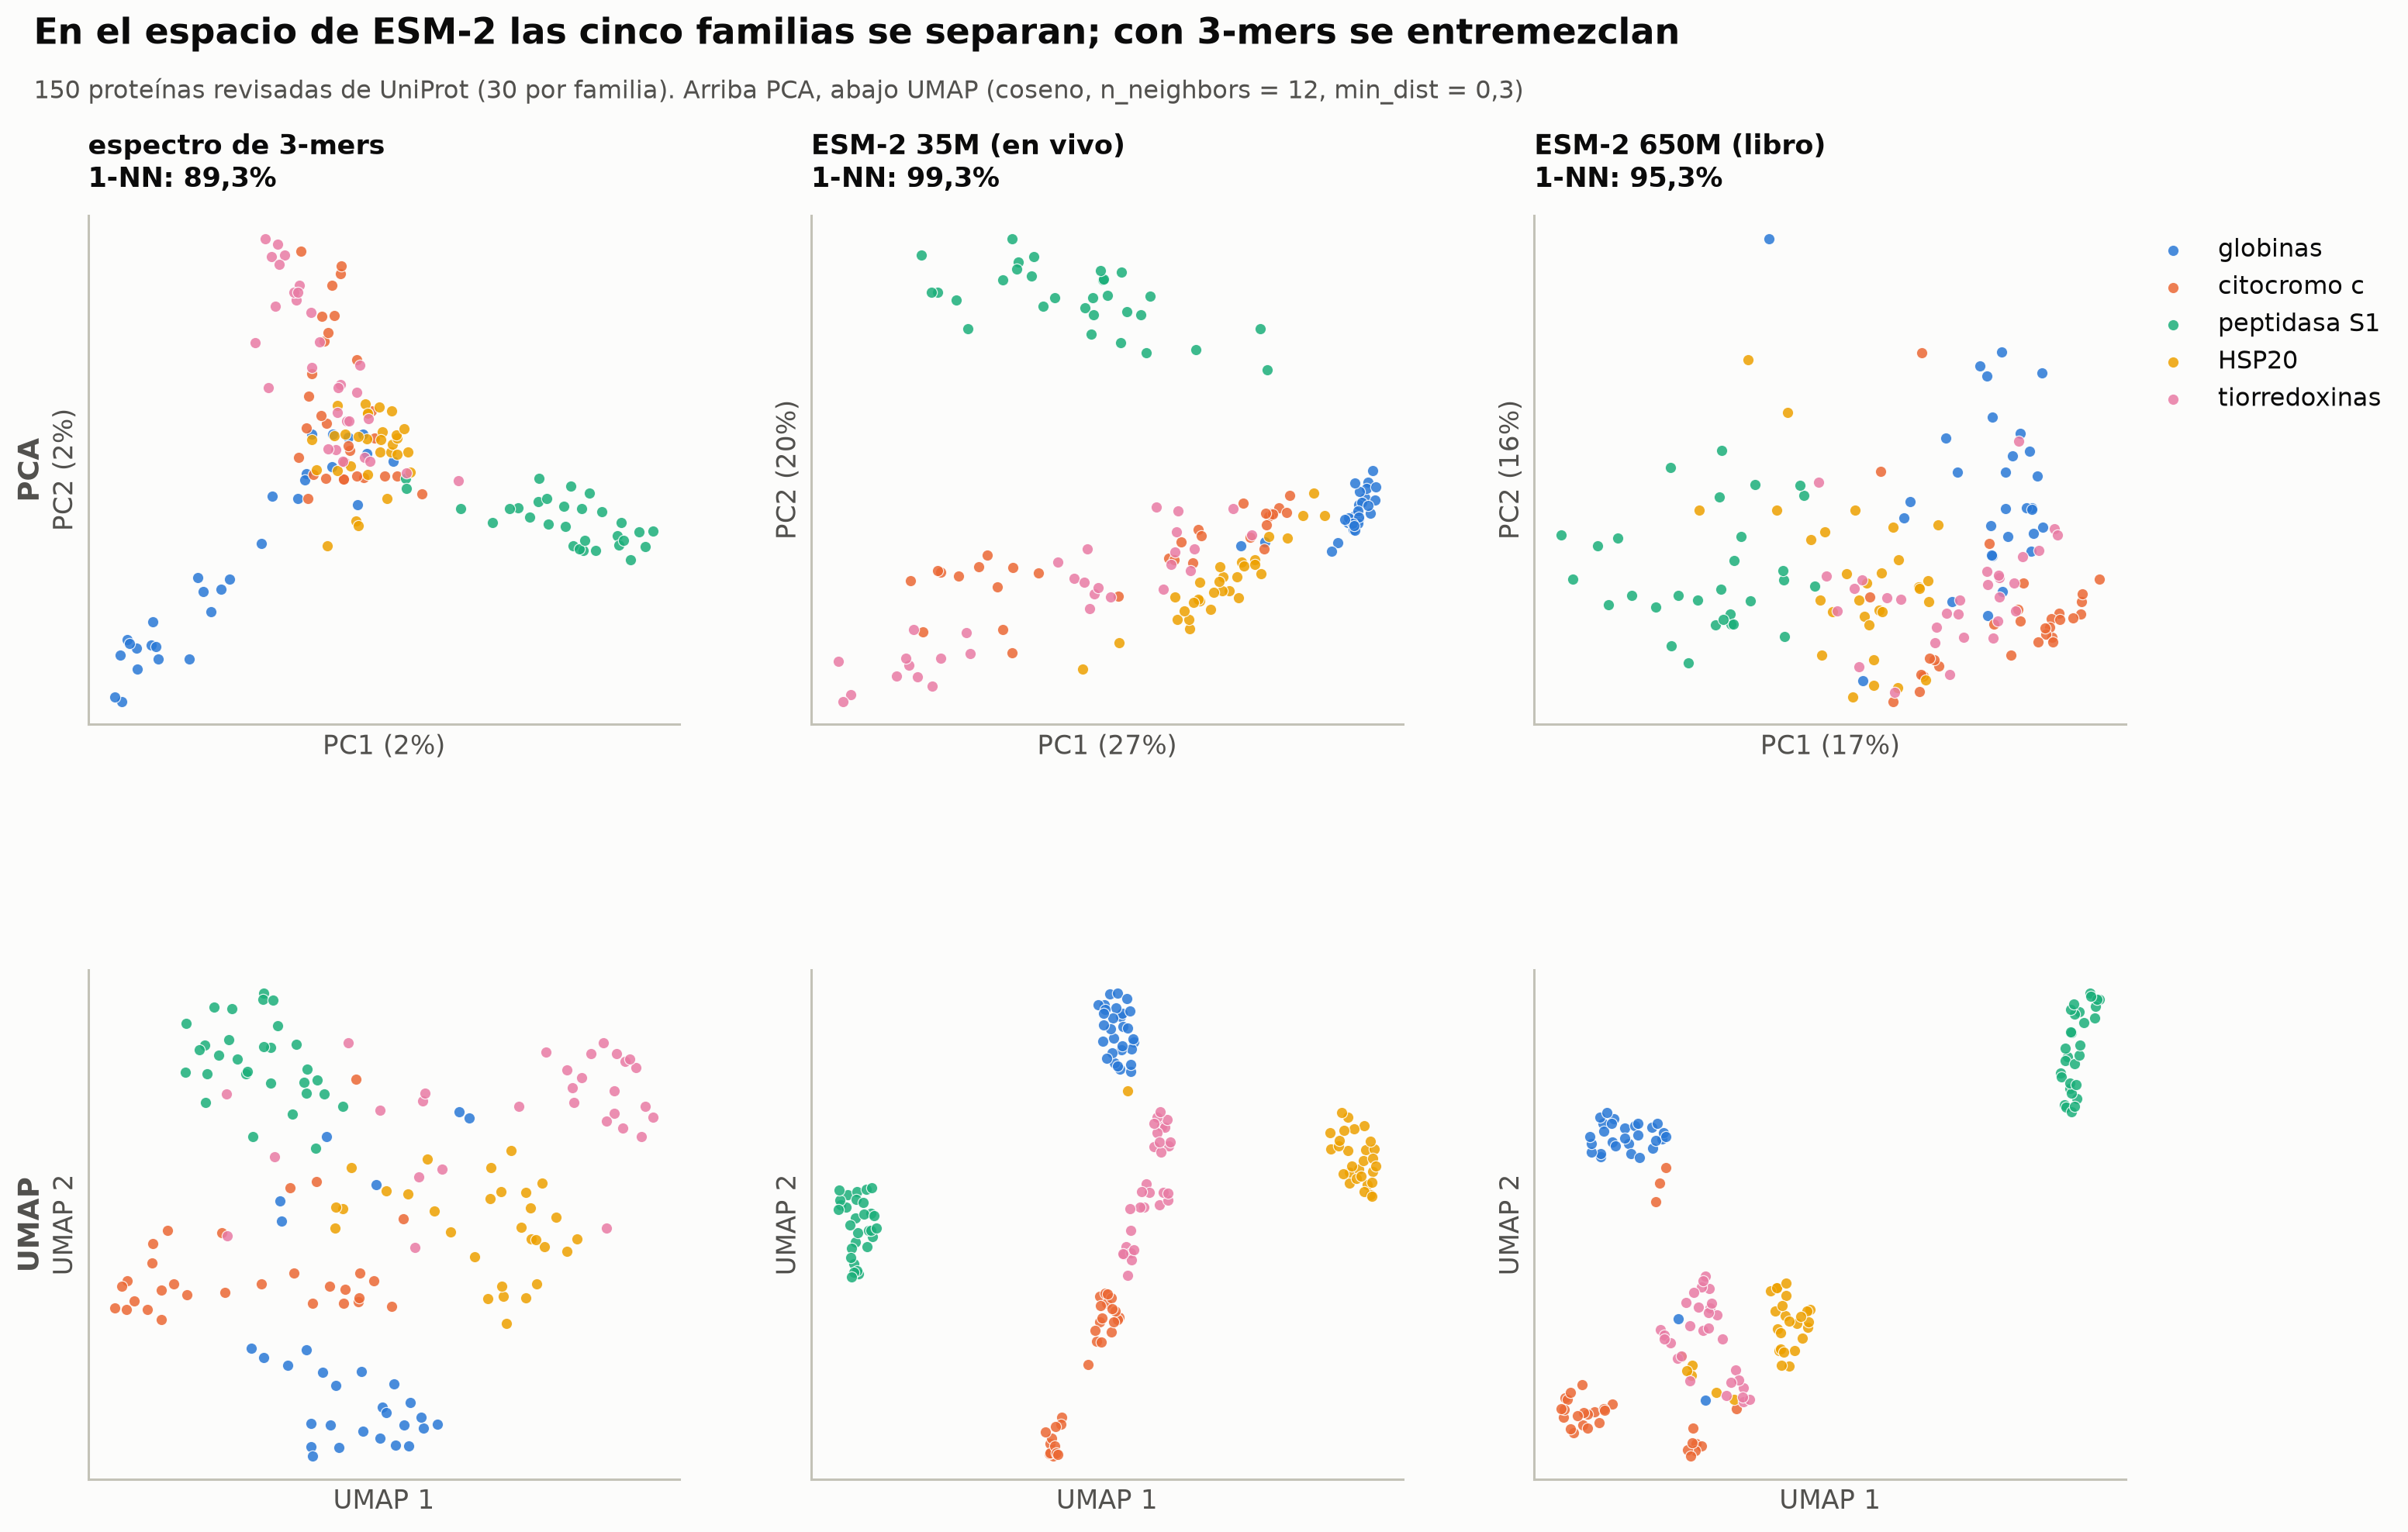

In [16]:
# PCA (lineal) y UMAP (no lineal) de cada representación
try:
    import umap
except ImportError:
    %pip install -q umap-learn
    import umap
from sklearn.decomposition import PCA

proj = {}
for name, Xm in (("espectro de 3-mers", KX), ("ESM-2 35M (en vivo)", EMB35), ("ESM-2 650M (libro)", EMB650)):
    Xn = unit(Xm)
    pca = PCA(n_components=2, random_state=17).fit(Xn)
    proj[name] = dict(pca=pca.transform(Xn), var=pca.explained_variance_ratio_,
                      umap=umap.UMAP(n_neighbors=12, min_dist=0.3, metric="cosine", random_state=17).fit_transform(Xn))

fig, axs = plt.subplots(2, 3, figsize=(14, 8.2), gridspec_kw=dict(hspace=0.3, wspace=0.12))
for c, name in enumerate(proj):
    for r, kind in enumerate(("pca", "umap")):
        ax = axs[r, c]; U = proj[name][kind]
        for k, f in enumerate(FAMILIES):
            sel = labels == k
            ax.scatter(U[sel, 0], U[sel, 1], s=22, color=ec.CATEGORICAL[k], alpha=0.85, lw=0.4, ec="white", label=f)
        ax.set_xticks([]); ax.set_yticks([])
        if kind == "pca":
            v = proj[name]["var"]
            ax.set_xlabel(f"PC1 ({v[0]:.0%})"); ax.set_ylabel(f"PC2 ({v[1]:.0%})")
            ax.set_title(f"{name}\n1-NN: {acc[name]:.1%}".replace(".", ","), loc="left", fontsize=11.5)
        else:
            ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
axs[0, 2].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10.5)
axs[0, 0].text(-0.12, 0.5, "PCA", transform=axs[0, 0].transAxes, rotation=90, va="center", fontsize=12, fontweight="bold", color=ec.INK_2)
axs[1, 0].text(-0.12, 0.5, "UMAP", transform=axs[1, 0].transAxes, rotation=90, va="center", fontsize=12, fontweight="bold", color=ec.INK_2)
ec.fig_title(fig, "En el espacio de ESM-2 las cinco familias se separan; con 3-mers se entremezclan",
             "150 proteínas revisadas de UniProt (30 por familia). Arriba PCA, abajo UMAP (coseno, n_neighbors = 12, min_dist = 0,3)")
plt.show()

> 🔎 **Qué observamos.** Con 3-mers, las proyecciones reflejan sobre todo la **composición de aminoácidos**: las familias se
> solapan y en PCA casi no hay estructura. Con ESM-2, incluso una proyección **lineal** (PCA) separa varias familias, y UMAP
> dibuja cinco islas. El modelo agrupa homólogos remotos que apenas comparten palabras idénticas: ha aprendido algo parecido a
> la noción de «familia» sin que nadie se la enseñara.

### 7.3 📊 Interactivo: explore el mapa de proteínas

Cada punto es una proteína real; el cursor muestra su identificador de UniProt, su nombre, el organismo y su vecino más
cercano en el espacio de ESM-2. Busque los pocos puntos que «caen» en una isla ajena: ¿qué tienen de especial?

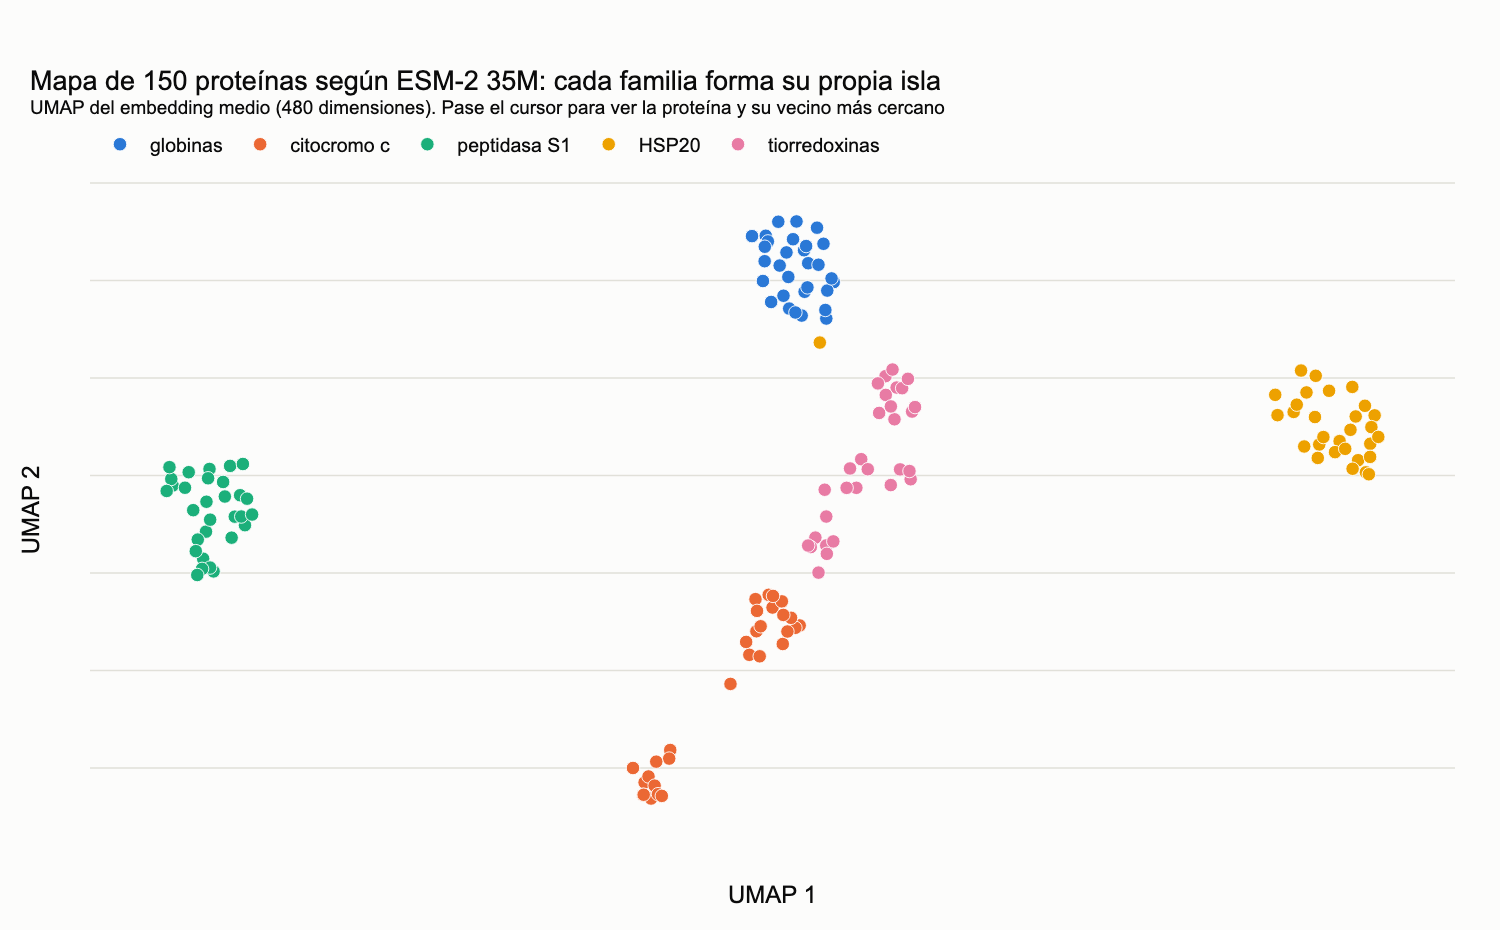

Proteínas cuyo vecino (35M) es de otra familia:
family       entry                                         protein             organism  length      vecino
 HSP20 ARID6_ARATH AT-rich interactive domain-containing protein 6 Arabidopsis thaliana     398 GLOB6_CAEEL


In [17]:
_, nn35 = nn_accuracy(EMB35)
U = proj["ESM-2 35M (en vivo)"]["umap"]
figE = go.Figure()
for k, f in enumerate(FAMILIES):
    sel = np.where(labels == k)[0]
    txt = [f"<b>{fam.accession[i]}</b> · {fam.entry[i]}<br>{fam.protein[i]}<br><i>{fam.organism[i]}</i> · {fam.length[i]} aa"
           f"<br>familia: {f}<br>vecino más cercano: {fam.entry[nn35[i]]} ({fam.family[nn35[i]]})"
           + ("<br>⚠️ su vecino es de otra familia" if labels[nn35[i]] != k else "") for i in sel]
    figE.add_trace(go.Scatter(x=U[sel, 0], y=U[sel, 1], mode="markers", name=f, text=txt,
                              hovertemplate="%{text}<extra></extra>",
                              marker=dict(size=9, color=ec.CATEGORICAL[k], line=dict(width=0.6, color="white"))))
figE.update_layout(width=900, height=620, margin=dict(l=60, r=30, t=120, b=60),
                   title="Mapa de 150 proteínas según ESM-2 35M: cada familia forma su propia isla"
                         "<br><sup>UMAP del embedding medio (480 dimensiones). Pase el cursor para ver la proteína y su vecino más cercano</sup>",
                   xaxis=dict(title="UMAP 1", showticklabels=False), yaxis=dict(title="UMAP 2", showticklabels=False),
                   legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
figE.show()
wrong = np.where(labels[nn35] != labels)[0]
print("Proteínas cuyo vecino (35M) es de otra familia:")
print(fam.loc[wrong, ["family", "entry", "protein", "organism", "length"]].assign(vecino=fam.entry[nn35[wrong]].values).to_string(index=False))

---

## 8. Predicción de efectos de mutaciones sin supervisión

### 8.1 Una mutación «que suena mal»

Si le leen la frase «El gato persiguió al ratón por el **jardím**», usted nota el error sin consultar un diccionario: esa
palabra es improbable en ese contexto. La idea, formalizada por Meier et al. (2021), es la misma: el modelo ya ha
aprendido qué secuencias son «gramaticales» para la evolución; si una mutación convierte la proteína en algo improbable
para el modelo, **probablemente sea perjudicial**. Se llama predicción *zero-shot* porque no usa ningún dato experimental
de entrenamiento.

### 8.2 El marginal enmascarado

La puntuación de **marginal enmascarado** de una variante con posiciones mutadas $M$ es

$$
s(x^{\text{mut}}) = \sum_{i\in M}\Big[\log p_{\boldsymbol\theta}\big(x_i = x_i^{\text{mut}}\,\big|\,x_{\setminus M}\big) - \log p_{\boldsymbol\theta}\big(x_i = x_i^{\text{wt}}\,\big|\,x_{\setminus M}\big)\Big].
$$

| Símbolo | Significado |
|---|---|
| $x_i^{\text{wt}},\ x_i^{\text{mut}}$ | Aminoácido silvestre (*wild type*) y mutante en la posición $i$ |
| $x_{\setminus M}$ | Secuencia silvestre con las posiciones mutadas enmascaradas |
| $s(x^{\text{mut}})$ | Razón de log-verosimilitudes (LLR, en nats): negativa si el modelo prefiere el silvestre |

Es un viejo conocido con ropa nueva: igual que la puntuación de una matriz de sustitución (Lección 3.3) o de una PWM
(Lección 4.2), es el **logaritmo de una razón de probabilidades**, sólo que ahora la probabilidad depende de *todo el
contexto* de la proteína concreta y no de una tabla fija. Con una sola pasada del modelo por posición (¡ya la hicimos en la
sección 5!) se obtiene el paisaje completo de las $19L$ mutaciones puntuales posibles.

**Ejemplo a mano.** En E24 el modelo grande da $p(\text{A})=0{,}387$ y $p(\text{E})=0{,}027$, así que
$s(\text{E24A})=\ln(0{,}387/0{,}027)=\ln 14{,}3\approx+2{,}66$ nats: el modelo prefiere la alanina al glutamato nativo.

In [18]:
def llr_matrix(logp, seq):
    """Paisaje de marginal enmascarado: matriz 20 × L con s = log p(mut) − log p(wt) (0 en el silvestre)."""
    wt = np.array([AA.index(c) for c in seq])
    return (logp - logp[np.arange(len(seq)), wt][:, None]).T

LLR35 = llr_matrix(LOGP_H, UBQ_HUMAN)
LLR650 = BOOK650["LLR"].astype(float)            # el libro guarda el paisaje calculado con 650M
print("¿La matriz del libro coincide con la reconstruida desde sus log-probabilidades?",
      np.allclose(LLR650, llr_matrix(LOGP_650, UBQ_HUMAN), atol=1e-3))

def s(LLR, mut):
    wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]
    assert UBQ_HUMAN[pos - 1] == wt
    return LLR[AA.index(mt), pos - 1]

rows = []
for mut in ["I44V", "I44A", "I44D", "E24A", "G47A", "G75A", "G76A"]:
    rows.append(dict(variante=mut, **{"LLR 650M (libro)": s(LLR650, mut), "LLR 35M (en vivo)": s(LLR35, mut)}))
print(pd.DataFrame(rows).round(2).to_string(index=False))
p24 = np.exp(LOGP_650[23])
print(f"\nE24A a mano: ln({p24[AA.index('A')]:.3f}/{p24[AA.index('E')]:.3f}) = "
      f"{np.log(p24[AA.index('A')] / p24[AA.index('E')]):.2f} nats")
for name, M in (("650M", LLR650), ("35M", LLR35)):
    frac = (M < -1e-9).sum() / (19 * L)
    mean_pos = M.sum(0) / 19
    o = np.argsort(mean_pos)
    print(f"\n{name}: {frac:.1%} de las sustituciones con LLR < 0")
    print("  más intolerantes:", ", ".join(f"{UBQ_HUMAN[i]}{i+1} ({mean_pos[i]:.2f})" for i in o[:8]))
    print("  más tolerantes:  ", ", ".join(f"{UBQ_HUMAN[i]}{i+1} ({mean_pos[i]:.2f})" for i in o[-6:]))

¿La matriz del libro coincide con la reconstruida desde sus log-probabilidades? True
variante  LLR 650M (libro)  LLR 35M (en vivo)
    I44V             -5.10              -1.96
    I44A             -9.54              -4.84
    I44D            -13.62              -8.39
    E24A              2.66              -0.19
    G47A             -8.13              -5.21
    G75A             -7.18              -3.53
    G76A             -1.30              -1.84

E24A a mano: ln(0.387/0.027) = 2.66 nats

650M: 97.6% de las sustituciones con LLR < 0
  más intolerantes: G47 (-11.47), I44 (-11.46), K6 (-10.60), K27 (-10.42), F45 (-10.20), G10 (-10.07), L69 (-10.04), V70 (-9.96)
  más tolerantes:   P38 (-2.78), N25 (-2.65), K63 (-2.24), D32 (-1.99), A28 (-1.37), E24 (-0.64)

35M: 92.5% de las sustituciones con LLR < 0
  más intolerantes: M1 (-8.84), L43 (-8.48), L56 (-7.39), I30 (-7.07), V5 (-6.88), I23 (-6.82), G47 (-6.68), I3 (-6.64)
  más tolerantes:   L73 (-0.95), R74 (-0.95), D39 (-0.64), N25 (-0.5

### 8.3 Ejemplo resuelto: «Leer el paisaje de la ubiquitina» (el mismo del libro)

En la **Ile44**, la sustitución conservadora I44V tiene LLR $=-5{,}10$ nats, I44A baja a $-9{,}54$ y la introducción de una
carga, I44D, a $-13{,}62$: el orden coincide con la intuición bioquímica de que un núcleo hidrofóbico tolera mejor otro
residuo hidrofóbico que un hueco o una carga. En el **Glu24**, en cambio, E24A tiene LLR $=\ln(0{,}387/0{,}027)\approx+2{,}66$:
el modelo considera la alanina *más* verosímil que el glutamato nativo.

El paisaje también muestra los límites del método. Las dos glicinas C-terminales (**Gly75 y Gly76**) son imprescindibles para
que la ubiquitina se conjugue con otras proteínas, pero el modelo penaliza G75A ($-7{,}18$) mucho más que G76A ($-1{,}30$). Un
modelo de lenguaje captura sobre todo las restricciones que la evolución imprime en muchas familias de proteínas
(plegamiento, empaquetamiento) y no necesariamente las funciones específicas de una proteína concreta; **sus puntuaciones son
hipótesis, no mediciones**.

> 🔎 **Qué observamos en la salida.** Las cifras del libro se reproducen exactamente (97,6 % de LLR negativos; G47, I44, K6,
> K27, F45, G10, L69 y V70 como posiciones más intolerantes; E24, A28, D32, K63 entre las más tolerantes). El modelo pequeño
> ordena igual a los tres mutantes de I44 (V > A > D) pero con valores menos extremos, y no llega a preferir la alanina en E24.

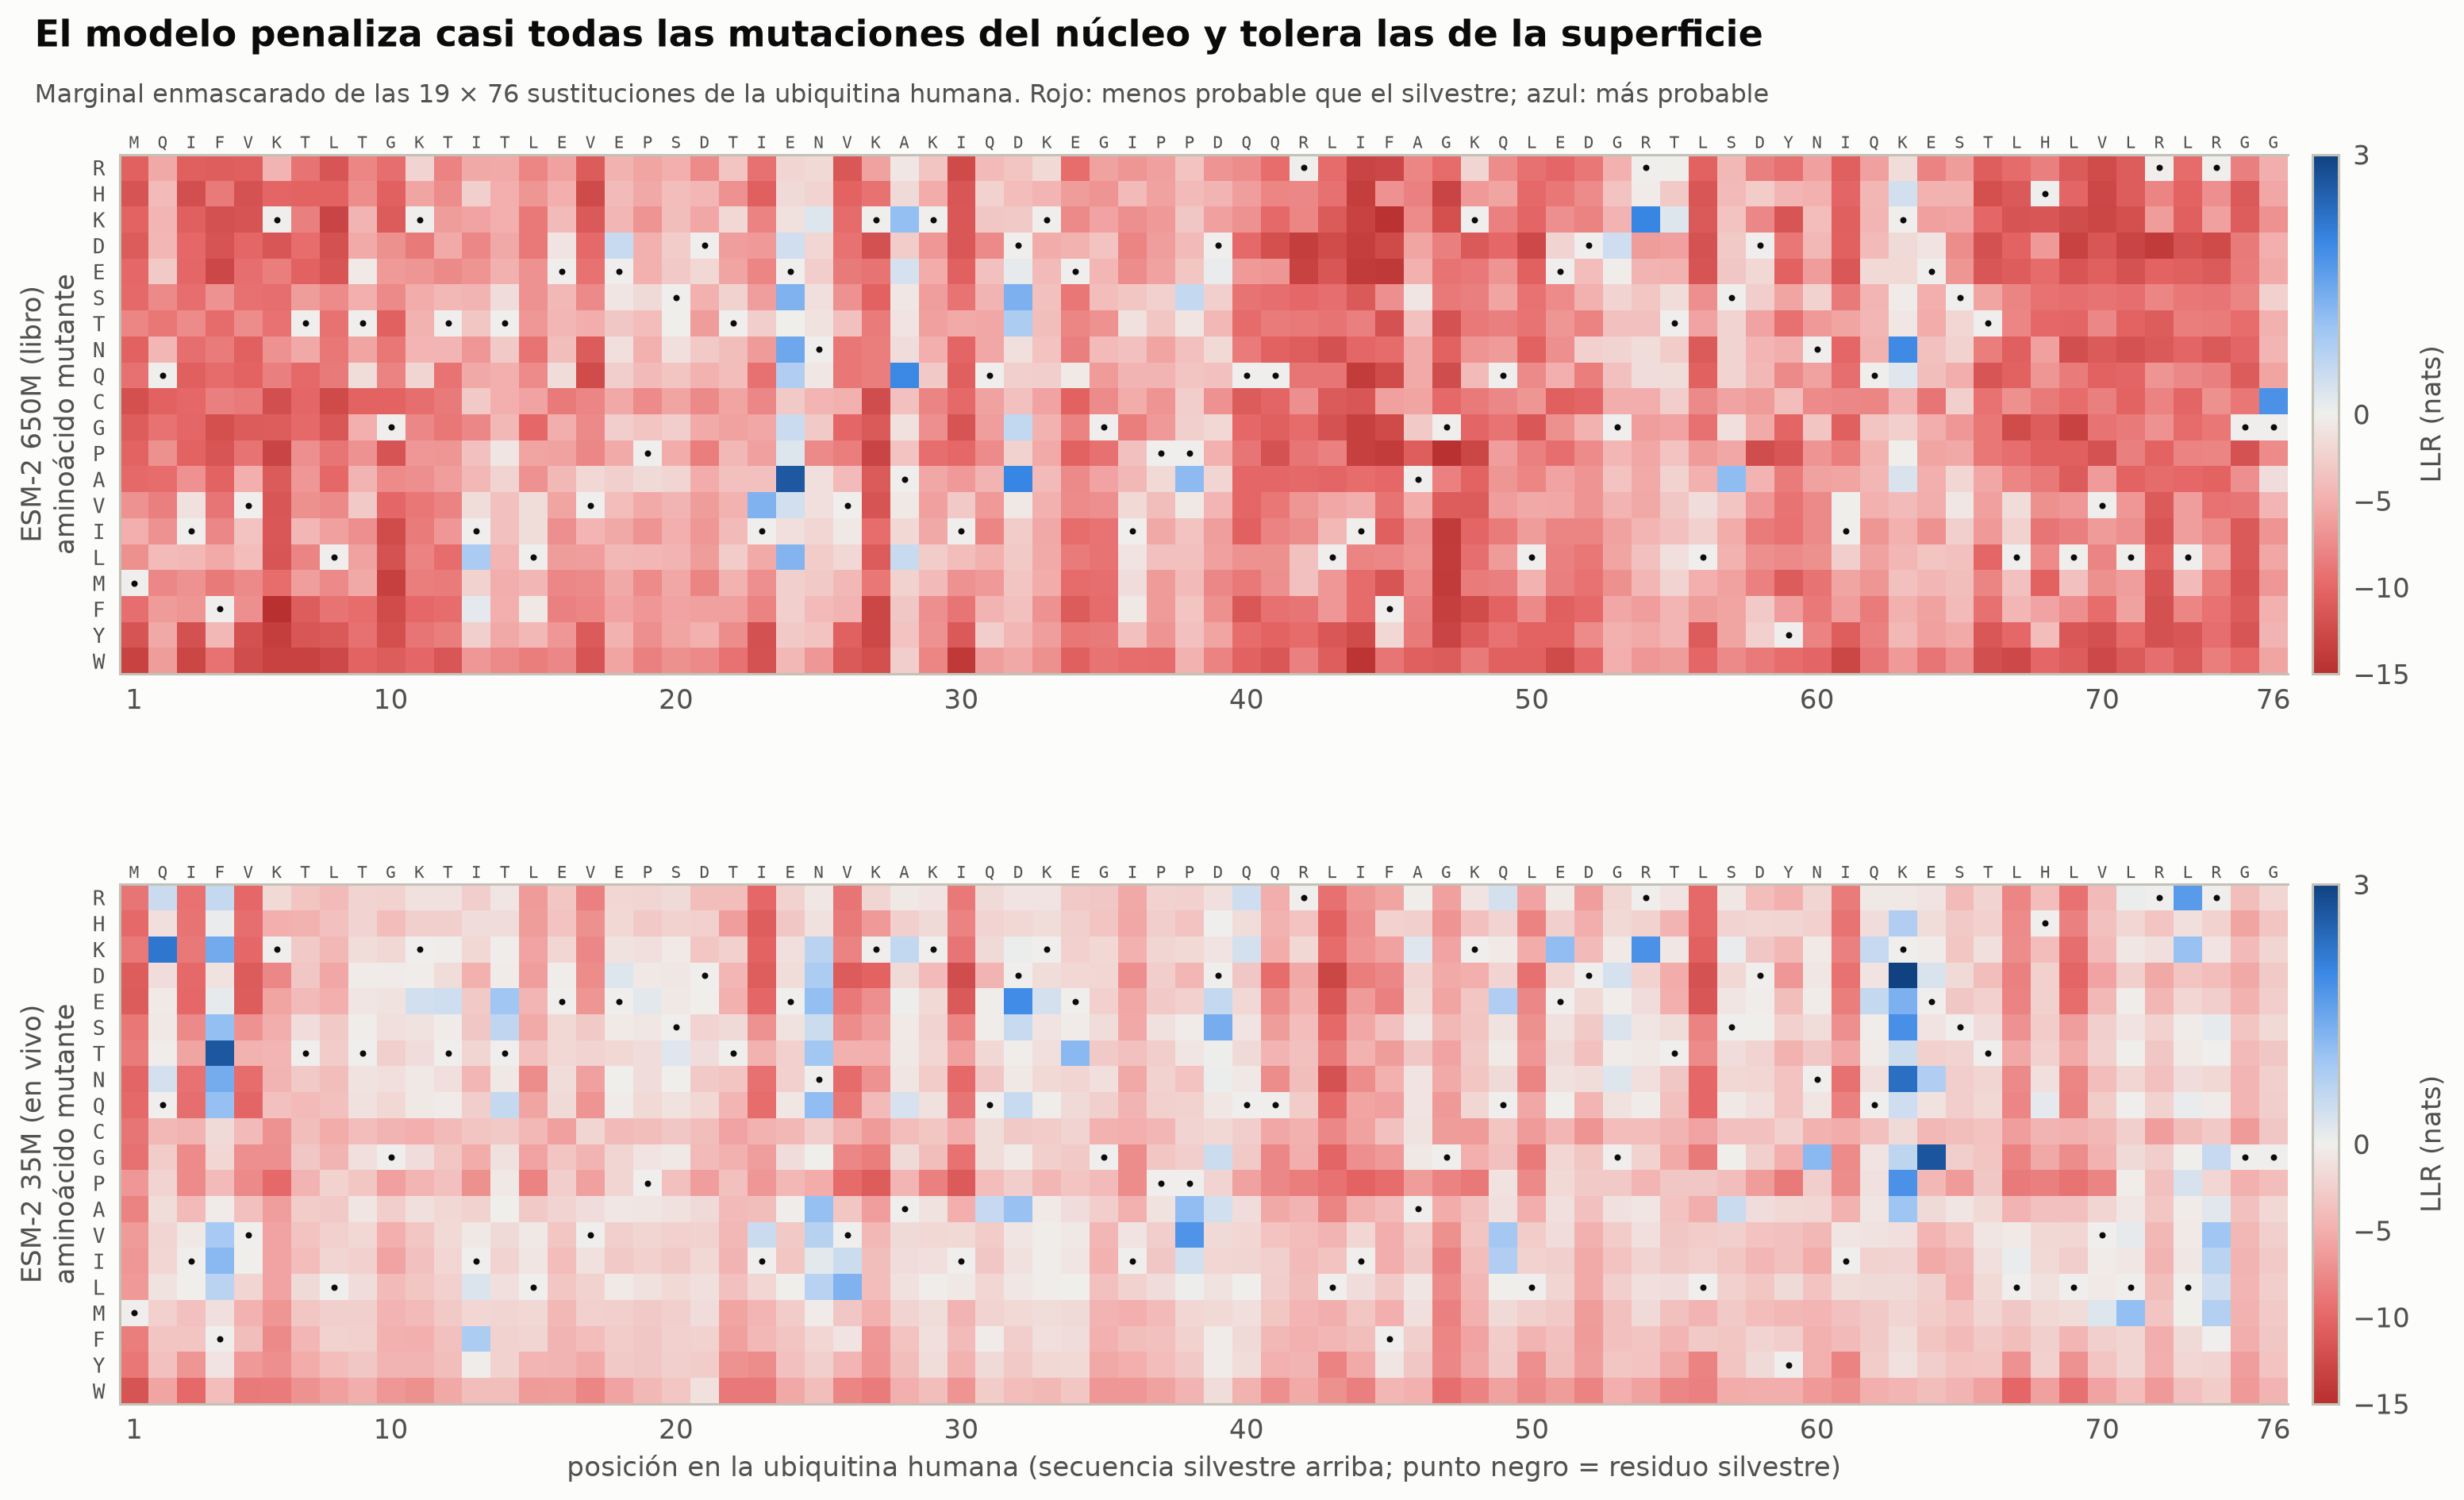

In [19]:
# Figura: los dos paisajes completos (19 × 76 sustituciones)
from matplotlib.colors import TwoSlopeNorm
fig, axs = plt.subplots(2, 1, figsize=(14, 7.8), gridspec_kw=dict(hspace=0.22))
for ax, M, name in ((axs[0], LLR650, "ESM-2 650M (libro)"), (axs[1], LLR35, "ESM-2 35M (en vivo)")):
    im = ax.imshow(M, aspect="auto", cmap=ec.CMAP_DIV.reversed(), norm=TwoSlopeNorm(0, vmin=-15, vmax=3), interpolation="nearest")
    for i, c in enumerate(UBQ_HUMAN):
        ax.plot(i, AA.index(c), "o", ms=2.6, color=ec.INK, mec="none")
    ax.set_yticks(range(20)); ax.set_yticklabels(list(AA), family="monospace", fontsize=8.5)
    xt = [0, 9, 19, 29, 39, 49, 59, 69, 75]
    ax.set_xticks(xt); ax.set_xticklabels([i + 1 for i in xt])
    top = ax.secondary_xaxis("top"); top.set_xticks(range(L)); top.set_xticklabels(list(UBQ_HUMAN), family="monospace", fontsize=7)
    top.tick_params(length=0, pad=1)
    ax.set_ylabel(f"{name}\naminoácido mutante"); ax.grid(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, ticks=[-15, -10, -5, 0, 3]); cb.set_label("LLR (nats)")
axs[1].set_xlabel("posición en la ubiquitina humana (secuencia silvestre arriba; punto negro = residuo silvestre)")
ec.fig_title(fig, "El modelo penaliza casi todas las mutaciones del núcleo y tolera las de la superficie",
             "Marginal enmascarado de las 19 × 76 sustituciones de la ubiquitina humana. Rojo: menos probable que el silvestre; azul: más probable")
plt.show()

> 🔎 **Qué observamos.** Columnas rojas de arriba abajo: posiciones intocables (I44, G47, K6, K27, F45, V70…). Columnas
> pálidas: posiciones expuestas donde el modelo acepta casi cualquier residuo (E24, A28, D32, K63). Filas: la prolina (P) y
> el triptófano (W) son malas sustituciones casi en todas partes. El modelo pequeño dibuja el mismo patrón con menos
> contraste; la correlación de Spearman entre ambos paisajes se pide en el Ejercicio 5.

### 8.4 📊 Interactivo: el paisaje mutacional completo, con el experimento al lado

Pase el cursor por cualquier celda: verá la LLR de ambos modelos y, si existe, el **coeficiente de selección medido** para
esa misma sustitución en levadura (Roscoe et al., 2013; sección 9). Con los botones puede cambiar el modelo que colorea el
mapa. Busque la columna de K48: ¿qué dice el modelo y qué dice el experimento?

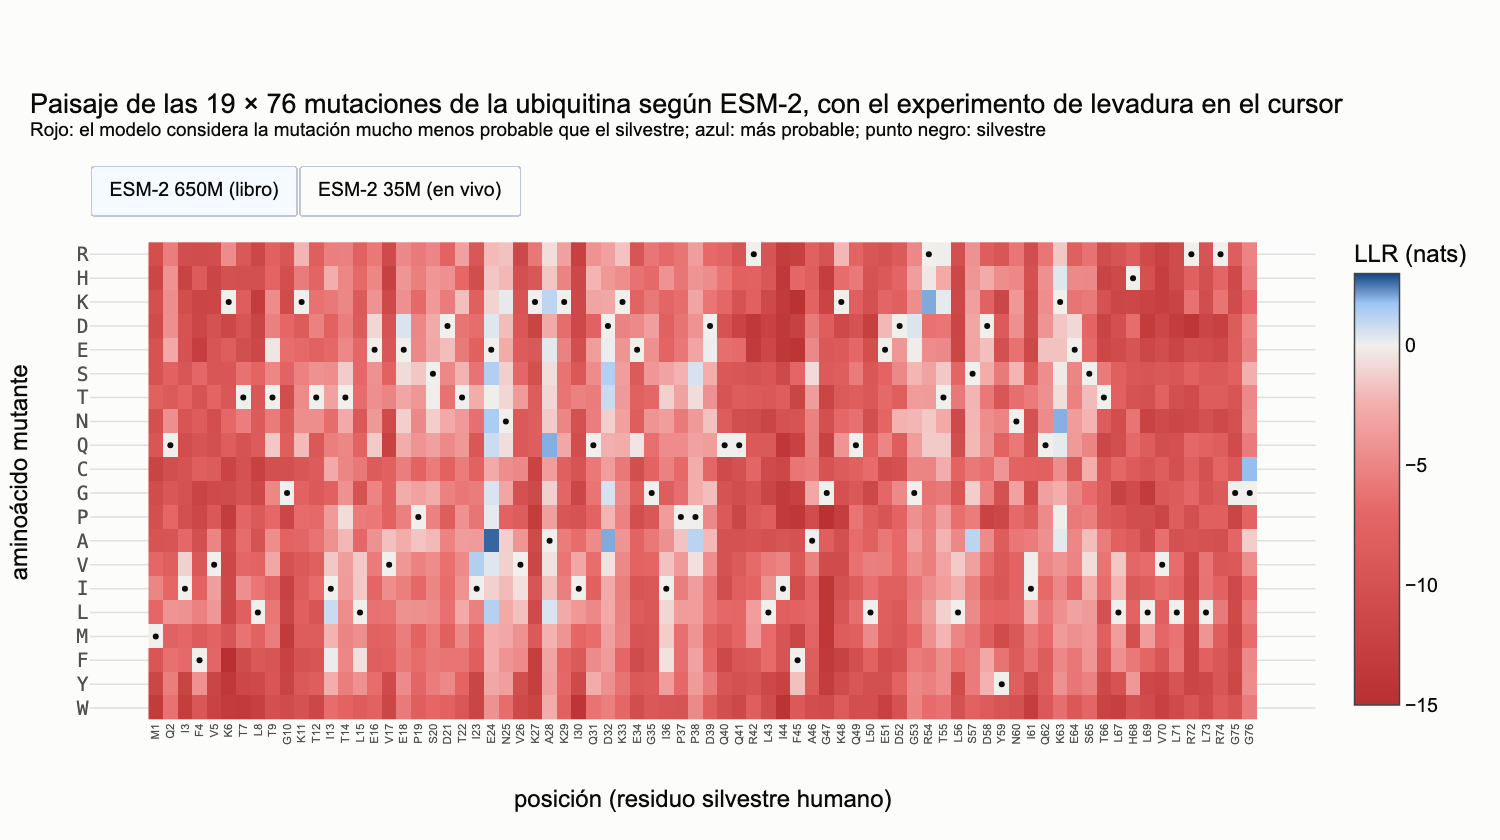

In [20]:
dms_map = {(p, m): v for p, m, v in zip(dms.pos, dms.mt, dms.DMS_score)}
DIFF_POS = {i + 1 for i, (a, b) in enumerate(zip(UBQ_HUMAN, UBQ_YEAST)) if a != b}

def dms_text(pos, mt):
    if UBQ_HUMAN[pos - 1] == mt:
        return "residuo silvestre"
    if pos in DIFF_POS:
        return f"no comparable: la levadura tiene {UBQ_YEAST[pos-1]}{pos}"
    v = dms_map.get((pos, mt))
    if v is None:
        return "no medido"
    verdict = "crece como el silvestre" if v > -0.1 else ("defecto moderado" if v > -0.5 else "defecto grave / letal")
    return f"{v:+.2f} ({verdict})"

hover = [[f"<b>{UBQ_HUMAN[i]}{i+1}{AA[a]}</b><br>LLR 650M (libro): {LLR650[a, i]:+.2f} nats<br>"
          f"LLR 35M (en vivo): {LLR35[a, i]:+.2f} nats<br>DMS en levadura: {dms_text(i + 1, AA[a])}"
          for i in range(L)] for a in range(20)]
zmin, zmax = -15, 3
cs = [[0, "#b8302f"], [0.45, "#e66767"], [0.7, "#f3b0ae"], [(0 - zmin) / (zmax - zmin), "#f0efec"], [0.93, "#9ec5f4"], [1, "#104281"]]
figL = go.Figure(go.Heatmap(z=LLR650, x=[f"{c}{i+1}" for i, c in enumerate(UBQ_HUMAN)], y=list(AA), text=hover,
                            hovertemplate="%{text}<extra></extra>", colorscale=cs, zmin=zmin, zmax=zmax,
                            colorbar=dict(title="LLR (nats)")))
figL.add_trace(go.Scatter(x=[f"{c}{i+1}" for i, c in enumerate(UBQ_HUMAN)], y=list(UBQ_HUMAN), mode="markers",
                          marker=dict(size=4, color="#0b0b0b"), hoverinfo="skip", showlegend=False))
figL.update_layout(
    width=1150, height=560, margin=dict(l=60, r=30, t=150, b=80),
    title="Paisaje de las 19 × 76 mutaciones de la ubiquitina según ESM-2, con el experimento de levadura en el cursor"
          "<br><sup>Rojo: el modelo considera la mutación mucho menos probable que el silvestre; azul: más probable; punto negro: silvestre</sup>",
    xaxis=dict(title="posición (residuo silvestre humano)", tickangle=-90, tickfont=dict(size=7.5), dtick=1),
    yaxis=dict(title="aminoácido mutante", autorange="reversed", dtick=1, tickfont=dict(family="monospace")),
    updatemenus=[dict(type="buttons", direction="right", x=0, xanchor="left", y=1.02, yanchor="bottom",
                      buttons=[dict(label="ESM-2 650M (libro)", method="restyle", args=[{"z": [LLR650]}, [0]]),
                               dict(label="ESM-2 35M (en vivo)", method="restyle", args=[{"z": [LLR35]}, [0]])])])
figL.show()

---

## 9. 🧬 Caso real: ¿acierta el modelo frente a 1195 mutantes medidos en levadura?

Hasta aquí las LLR han sido hipótesis. Ahora las contrastamos con un experimento. En 2013, el grupo de Daniel Bolon midió la
tasa de crecimiento de levaduras que dependían de **cada una** de las mutaciones puntuales de la ubiquitina (Roscoe et al.,
2013). Es un escenario típico de un laboratorio de ingeniería de proteínas o de un servicio de genética clínica: antes de
gastar meses en un experimento, ¿podemos anticipar qué posiciones no toleran cambios?

Dos cuidados metodológicos:

1. **La proteína medida es la de levadura.** Para el modelo pequeño repetimos los marginales enmascarados sobre la secuencia
   de levadura (ya lo hicimos en la sección 5). Para el modelo del libro sólo tenemos el paisaje humano, así que comparamos
   excluyendo las tres posiciones que difieren (19, 24 y 28).
2. **Usamos correlación de rangos (Spearman).** La LLR no está calibrada: sólo esperamos que **ordene** bien las variantes.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué correlación de Spearman espera entre la LLR y el crecimiento medido: ≈ 0,1, ≈ 0,4
> o ≈ 0,9? ¿Será mayor para el modelo grande?

In [21]:
from sklearn.metrics import roc_auc_score
LLR35_Y = llr_matrix(LOGP_Y, UBQ_YEAST)
dms["LLR35"] = [LLR35_Y[AA.index(m), p - 1] for p, m in zip(dms.pos, dms.mt)]
dms["LLR650"] = [LLR650[AA.index(m), p - 1] if p not in DIFF_POS else np.nan for p, m in zip(dms.pos, dms.mt)]
comp = dms.dropna(subset=["LLR650"])

res = {}
for name, col, d in (("35M (levadura, todas)", "LLR35", dms), ("35M (mismas variantes que 650M)", "LLR35", comp),
                     ("650M libro (humana, sin 19/24/28)", "LLR650", comp)):
    rho = spearmanr(d[col], d.DMS_score)[0]
    auc = roc_auc_score(d.DMS_score_bin, d[col])            # ¿separa toleradas (1) de no toleradas (0)?
    g = d.groupby("pos").agg(dms=("DMS_score", "mean"), llr=(col, "mean"))
    res[name] = {"n variantes": len(d), "Spearman (variantes)": rho, "AUC tolerada/no": auc,
                 "Spearman (medias por posición)": spearmanr(g.dms, g.llr)[0]}
pd.DataFrame(res).T.round(3)

,n variantes,Spearman (variantes),AUC tolerada/no,Spearman (medias por posición)
"35M (levadura, todas)",1195.0,0.421,0.725,0.374
35M (mismas variantes que 650M),1138.0,0.417,0.715,0.347
"650M libro (humana, sin 19/24/28)",1138.0,0.631,0.826,0.707


> 🔎 **Qué observamos.** Sin haber visto un solo dato experimental, el modelo del libro alcanza una correlación de Spearman de
> ≈ 0,63 por variante y ≈ 0,71 por posición; el pequeño, ≈ 0,42 y ≈ 0,37. Para un método sin supervisión es mucho: ordena
> correctamente buena parte de las variantes. Pero una correlación de 0,6 también deja un 60 % largo de la varianza de rangos
> sin explicar. Veamos **dónde** se equivoca.

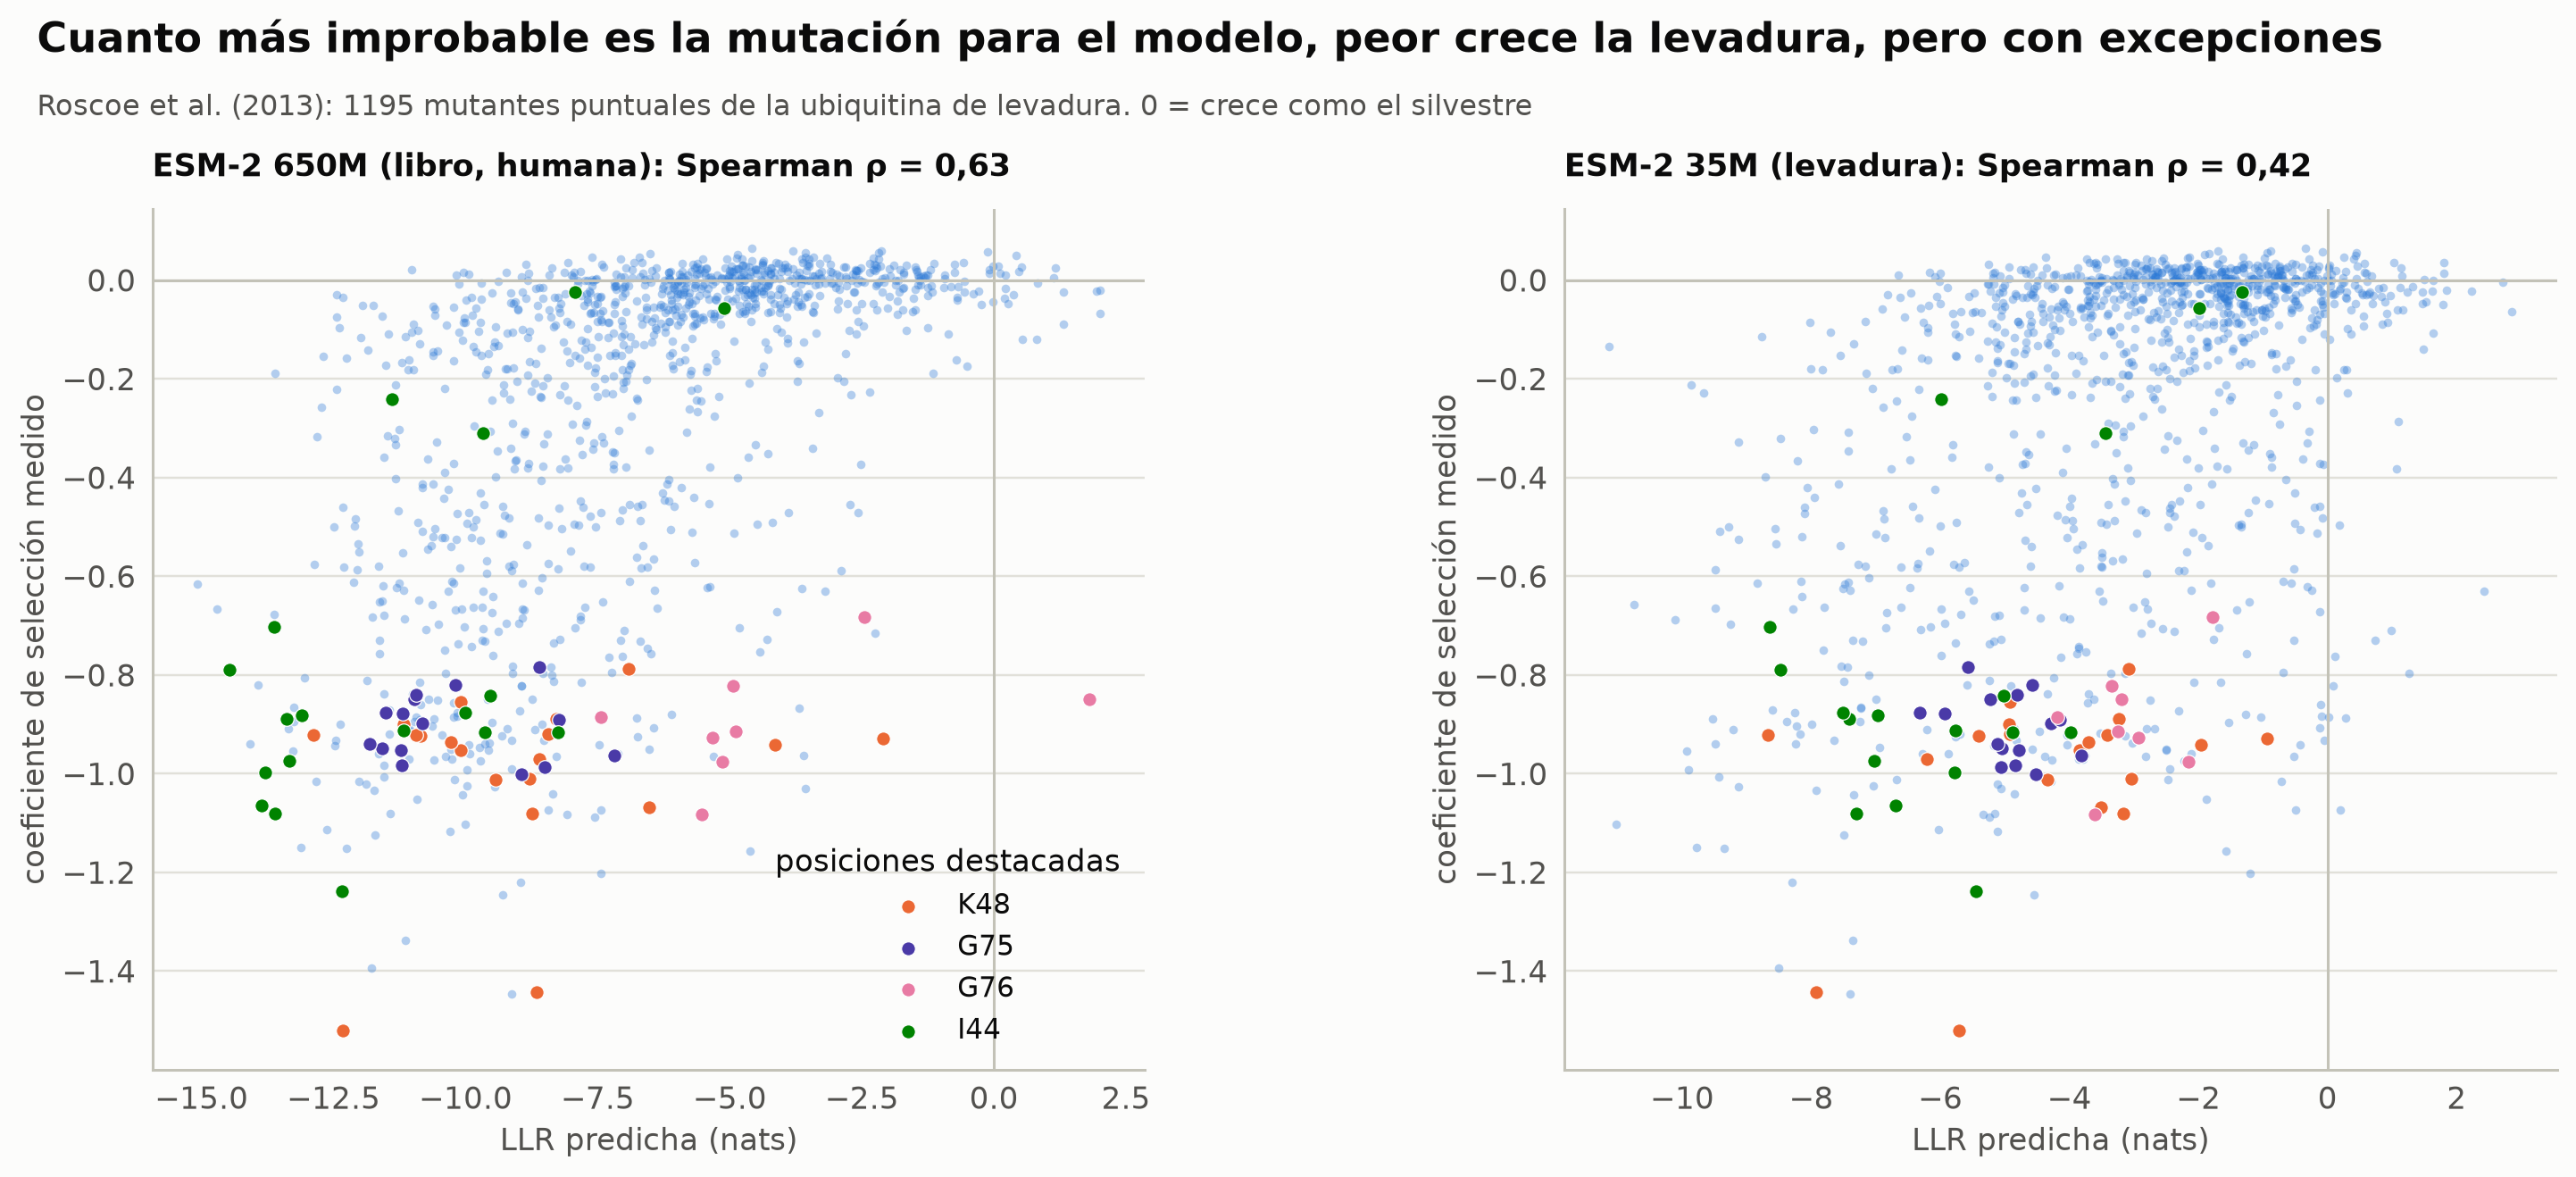

In [22]:
# Figura: LLR frente al coeficiente de selección medido
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(wspace=0.22))
highlight = {48: ec.ORANGE, 75: ec.VIOLET, 76: ec.MAGENTA, 44: ec.GREEN}
for ax, col, name, d in ((axs[0], "LLR650", "ESM-2 650M (libro, humana)", comp), (axs[1], "LLR35", "ESM-2 35M (levadura)", dms)):
    rest = d[~d.pos.isin(highlight)]
    ax.scatter(rest[col], rest.DMS_score, s=10, color=ec.BLUE, alpha=0.35, lw=0)
    for p, c in highlight.items():
        sel = d[d.pos == p]
        ax.scatter(sel[col], sel.DMS_score, s=26, color=c, lw=0.4, ec="white", label=f"{UBQ_HUMAN[p-1]}{p}")
    rho = spearmanr(d[col], d.DMS_score)[0]
    ax.axhline(0, color=ec.BASELINE, lw=1); ax.axvline(0, color=ec.BASELINE, lw=1)
    ax.set_xlabel("LLR predicha (nats)"); ax.set_ylabel("coeficiente de selección medido")
    ax.set_title(f"{name}: Spearman ρ = {rho:.2f}".replace(".", ","), loc="left", fontsize=11.5)
axs[0].legend(title="posiciones destacadas", frameon=False, loc="lower right")
ec.fig_title(fig, "Cuanto más improbable es la mutación para el modelo, peor crece la levadura, pero con excepciones",
             "Roscoe et al. (2013): 1195 mutantes puntuales de la ubiquitina de levadura. 0 = crece como el silvestre")
plt.show()

Posiciones más sensibles en el experimento:
residuo   dms  llr650  llr35
    K48 -1.00   -8.91  -4.37
    G75 -0.91  -10.19  -4.94
    G76 -0.89   -4.24  -3.05
    L71 -0.78   -9.14  -1.00
    I44 -0.76  -11.35  -5.76
    R74 -0.74   -8.97  -0.70
    V70 -0.73   -9.49  -3.32
    R42 -0.73   -8.99  -4.58
    L73 -0.71   -7.53  -1.09
    R72 -0.70   -9.89  -4.02

El modelo (650M) las cree tolerantes, pero el experimento dice que no:
residuo   dms  llr650  rank_dms  rank_650
    G76 -0.89   -4.24      0.04      0.83
    I36 -0.46   -4.18      0.24      0.85
    D32 -0.17   -1.80      0.65      1.00
    L73 -0.71   -7.53      0.12      0.46
    T14 -0.17   -3.55      0.64      0.93
    I13 -0.21   -4.38      0.57      0.82

El modelo (650M) las cree intolerantes, pero la levadura crece bien:
residuo   dms  llr650  rank_dms  rank_650
    F45 -0.18  -10.00      0.61      0.08
    D52  0.01   -7.43      0.96      0.47
    Q40 -0.16   -8.95      0.67      0.24
     K6 -0.32  -10.55      0.43  

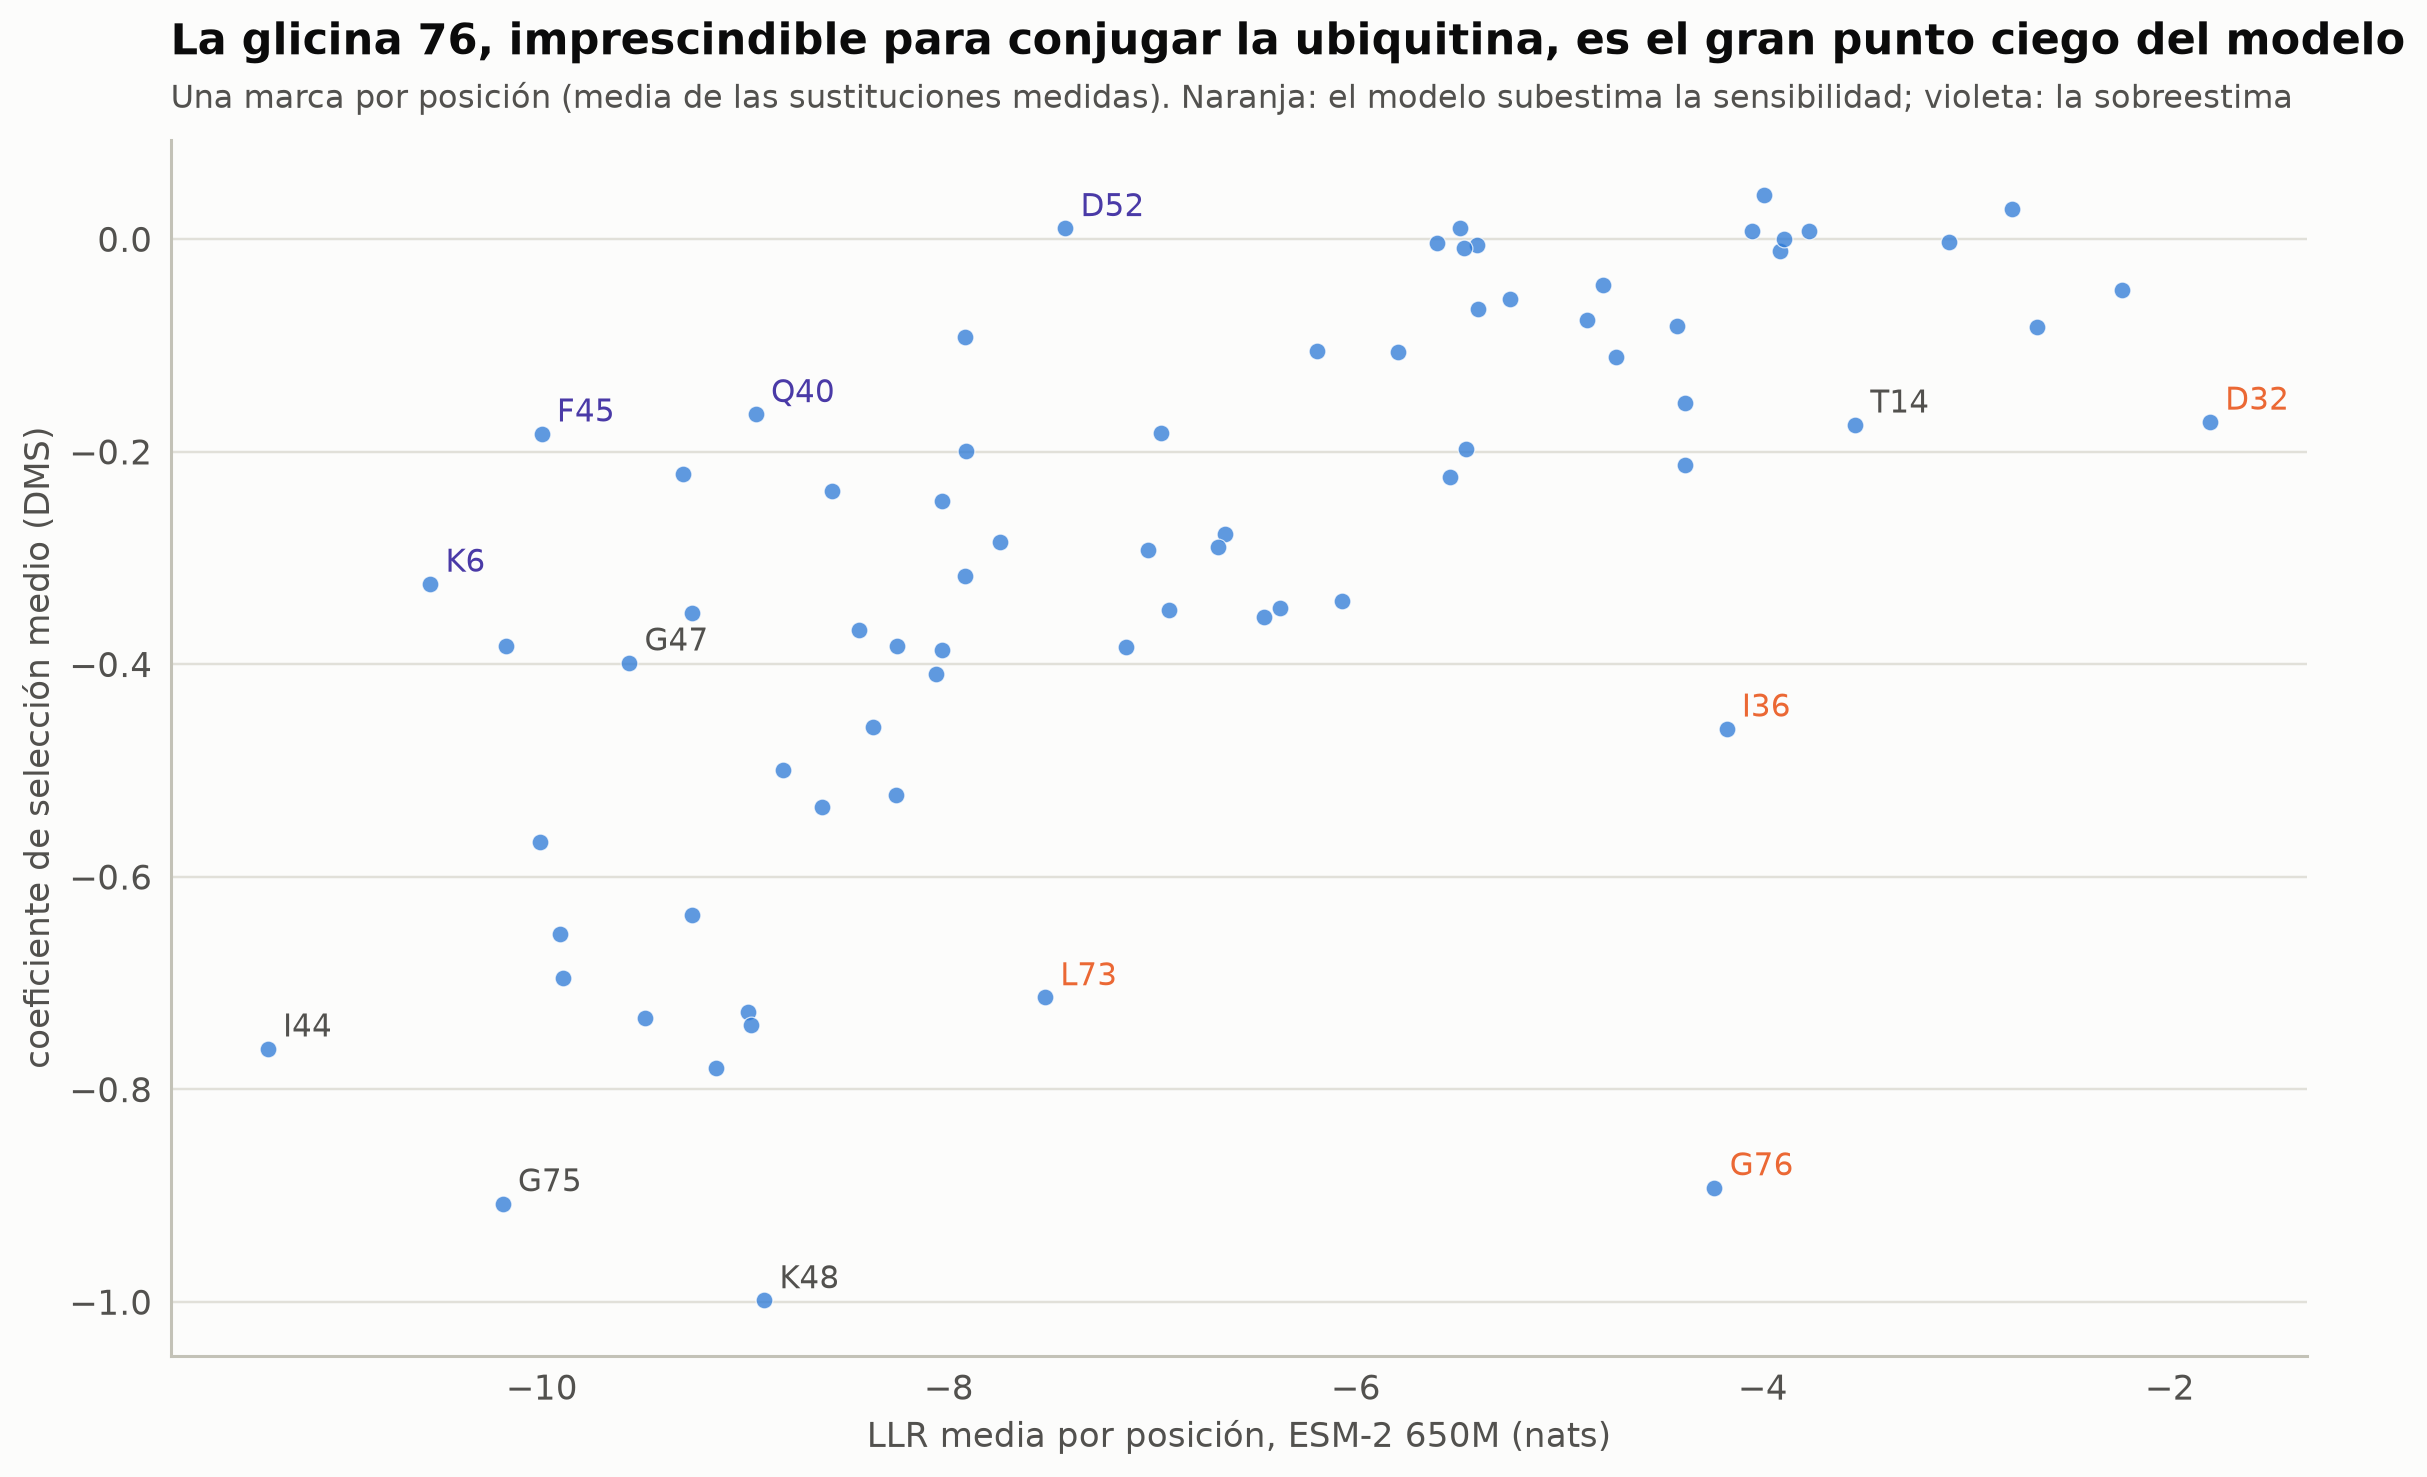

In [23]:
# ¿Dónde se equivoca? Comparamos, por posición, el rango de sensibilidad medida con el rango de sensibilidad predicha
g = comp.groupby("pos").agg(dms=("DMS_score", "mean"), llr650=("LLR650", "mean"), llr35=("LLR35", "mean"))
g["rank_dms"] = g.dms.rank(pct=True); g["rank_650"] = g.llr650.rank(pct=True)
g["residuo"] = [f"{UBQ_HUMAN[p-1]}{p}" for p in g.index]
g["desacuerdo"] = g.rank_650 - g.rank_dms      # > 0: el modelo la cree tolerante, el experimento no
print("Posiciones más sensibles en el experimento:")
print(g.sort_values("dms").head(10)[["residuo", "dms", "llr650", "llr35"]].round(2).to_string(index=False))
print("\nEl modelo (650M) las cree tolerantes, pero el experimento dice que no:")
print(g.sort_values("desacuerdo", ascending=False).head(6)[["residuo", "dms", "llr650", "rank_dms", "rank_650"]].round(2).to_string(index=False))
print("\nEl modelo (650M) las cree intolerantes, pero la levadura crece bien:")
print(g.sort_values("desacuerdo").head(6)[["residuo", "dms", "llr650", "rank_dms", "rank_650"]].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6.6))
ax.scatter(g.llr650, g.dms, s=30, color=ec.BLUE, alpha=0.75, lw=0.4, ec="white")
lab_pos = set(g.sort_values("desacuerdo").index[:4]) | set(g.sort_values("desacuerdo").index[-5:]) | {44, 47, 48, 75, 76}
for p in lab_pos:
    col = ec.ORANGE if g.desacuerdo[p] > 0.3 else (ec.VIOLET if g.desacuerdo[p] < -0.3 else ec.INK_2)
    ax.annotate(g.residuo[p], (g.llr650[p], g.dms[p]), xytext=(5, 4), textcoords="offset points", fontsize=10, color=col)
ax.set_xlabel("LLR media por posición, ESM-2 650M (nats)"); ax.set_ylabel("coeficiente de selección medio (DMS)")
ec.title(ax, "La glicina 76, imprescindible para conjugar la ubiquitina, es el gran punto ciego del modelo",
         "Una marca por posición (media de las sustituciones medidas). Naranja: el modelo subestima la sensibilidad; violeta: la sobreestima")
plt.show()

> 🔎 **Qué observamos.** Las posiciones más sensibles en el experimento son **K48** (la lisina con la que se forman las
> cadenas de poliubiquitina que llevan las proteínas al proteasoma), **G75 y G76** (la cola que se une a las proteínas
> diana), el parche hidrofóbico (**I44, V70**; su tercer miembro, L8, queda justo detrás, en el puesto 11), **R42** y la cola
> C-terminal (**L71, R72, L73, R74**). El modelo del libro acierta con
> la mayoría, pero con dos tipos de error instructivos:
>
> * **Subestima (naranja)** la sensibilidad de **G76**: todas sus sustituciones son casi letales, pero el modelo apenas las
>   penaliza (G76A: −1,30). Es exactamente la advertencia del ejemplo resuelto: la evolución de *muchas* familias le enseña
>   restricciones de plegamiento; la función química de un residuo concreto de *esta* proteína (formar el enlace
>   isopeptídico) es menos visible en las estadísticas de secuencias. El modelo pequeño comete además errores graves en
>   L71, L73 y R74.
> * **Sobreestima (violeta)** la sensibilidad de posiciones muy conservadas como **K6, F45 o Q40**, que en el cultivo de
>   laboratorio toleran muchas sustituciones. La evolución integra presiones de millones de años y de muchos ambientes;
>   un experimento mide una condición. Mavor et al. (2016) repitieron el experimento bajo distintos estreses químicos y
>   encontraron que el paisaje cambia con la condición.
>
> ✅ **Compruebe su comprensión.** Un colega propone usar «LLR < −5» como umbral para declarar patogénica una variante
> humana. Con lo que acaba de ver, dé dos objeciones. *Respuesta posible:* (1) la LLR no está calibrada: en la ubiquitina,
> el 70 % de las sustituciones tienen LLR < −5 (650M) y, de las medidas, más de un tercio crece casi como el silvestre; (2) el modelo falla justo en
> posiciones de función específica (G76), que son a menudo las clínicamente relevantes; hay que calibrar con datos
> clínicos o experimentales (ClinVar, DMS) antes de usar un umbral.

---

## 10. Riesgos y limitaciones

Los modelos de esta clase son herramientas poderosas, y precisamente por eso conviene conocer sus puntos débiles:

* **Fuga de información a escala de base de datos.** Los modelos de lenguaje se entrenan con casi todas las proteínas
  conocidas. Evaluar un modelo derivado sobre un conjunto de prueba cuyas secuencias (u homólogos cercanos) estaban en el
  preentrenamiento reproduce, a gran escala, el problema de fuga por homología de la Lección 17.1. Las recomendaciones
  DOME (Walsh et al., 2021) se aplican igual.
* **Sesgo de representación.** Las bases de datos están dominadas por organismos modelo, patógenos y familias muy
  estudiadas. El modelo es más fiable allí donde menos lo necesitamos: la baja pseudo-perplejidad de la ubiquitina
  (1,78 con 650M) refleja en parte que ha visto miles de sus homólogos.
* **Probabilidades que no son probabilidades.** Una LLR de −9 no significa que la variante sea patogénica con una
  probabilidad determinada; hay que calibrarla (sección 9).
* **Interpretabilidad limitada.** Saliencia y atención indican *dónde* mira el modelo, no *por qué*; una cabeza de atención
  que coincide con los contactos (sección 6.3) no demuestra que el modelo «entienda» la física del plegamiento.
* **Costes y acceso.** Entrenar un modelo de miles de millones de parámetros exige recursos que pocos laboratorios tienen;
  usar modelos preentrenados es asequible, pero hace depender la investigación de las decisiones de quien los entrenó.

> 🔬 **Profundización: por qué funciona, una lectura estadística.** El modelo óptimo para la pérdida MLM es aquel cuya
> $p_{\boldsymbol\theta}(x_i\mid x_{\setminus i})$ coincide con la distribución condicional real de las secuencias
> naturales. Esas secuencias están moldeadas por la selección: si una sustitución destruye la función, los linajes que la
> portan desaparecen y la sustitución es rara en las bases de datos. La LLR estima, por tanto, un cociente de aptitudes
> relativas integrado a lo largo de toda la historia evolutiva de la familia. Los modelos de familia única (perfiles,
> modelos de Potts de la Lección 15.2) hacen la misma estimación con un alineamiento; los modelos de lenguaje comparten
> parámetros entre todas las familias, lo que les permite funcionar con familias pequeñas o sin alineamiento posible, a
> cambio de mezclar a veces señales de familias distintas.

> 📜 **Historia: de la traducción automática a las proteínas.** El *transformer* nació en 2017 para traducir del inglés al
> alemán y al francés (Vaswani et al., 2017). Dos años después, BERT mostró que un *transformer* preentrenado con palabras
> enmascaradas podía adaptarse a casi cualquier tarea de lenguaje (Devlin et al., 2019). La biología computacional adoptó
> la receta casi de inmediato: la primera versión del trabajo de Rives et al. (2021) circuló como preprint en 2019, y en
> sólo cuatro años se pasó de la idea a un atlas de más de 617 millones de estructuras predichas (Lin et al., 2023). El
> consejo de George Box (1976) sigue siendo el mejor para usarlos: ningún modelo es correcto; la pregunta útil es en qué se
> equivoca de forma importante.

> 💡 **Idea clave.** Un modelo de lenguaje de proteínas es un perfil de familia generalizado a toda la evolución: sus
> probabilidades condicionales resumen qué ha tolerado la selección en cada contexto.

---

## 11. 🏋️ Ejercicios

**Ejercicio 1 (atención a mano).** Cambie la consulta de la lisina a $\mathbf{q}_3=(2, 0)$ en el ejemplo de los cuatro
residuos. Calcule a mano la fila $A_{3\cdot}$ y la salida $\mathbf{z}_3$, y compruébelo con `attention`. ¿Qué «busca» ahora la
lisina?

**Ejercicio 2 (temperatura de la softmax).** Repita el ejemplo de los cuatro residuos dividiendo las puntuaciones entre
$\tau\sqrt{d_k}$ con $\tau\in\{0{,}25;\ 1;\ 4\}$. ¿Qué le pasa a $A_{1\cdot}$ en cada caso? Relacione el resultado con la
sección 4.

**Ejercicio 3 (perplejidad).** Calcule la pseudo-perplejidad de la ubiquitina de **levadura** con el modelo pequeño y
compárela con la humana. Luego calcule la perplejidad de un «modelo» que siempre predice la composición media de
aminoácidos de la propia ubiquitina. ¿Cuánto mejora ESM-2 sobre esa referencia?

**Ejercicio 4 (contactos de largo alcance).** Para el modelo pequeño, dibuje la precisión top-$L$ en función de la
separación mínima $|i-j|\ge s$ con $s = 6, 12, 18, 24$. ¿Empeora la predicción con la distancia en la secuencia?

**Ejercicio 5 (el Ejercicio 9 del libro).** Calcule la correlación de Spearman entre el paisaje de 35M y el de 650M
(excluya las celdas del silvestre). ¿En qué posición difieren más los dos modelos (media de $|$LLR$_{35}-$LLR$_{650}|$)?

**Ejercicio 6 (aprendizaje por transferencia).** Entrene una regresión logística sobre los *embeddings* de 35M para
predecir la familia de las 150 proteínas, con validación cruzada estratificada de 5 particiones (Lección 17.1). Compare con
la misma regresión sobre espectros de 3-mers.

**Ejercicio 7 (DMS por aminoácido).** Con los datos de Roscoe et al., calcule, para cada aminoácido **mutante**, la media del
coeficiente de selección y la media de la LLR de 650M. ¿Coinciden en señalar a la prolina como el peor sustituto?

In [24]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
Q2 = Q.copy(); Q2[2] = [2.0, 0.0]
_, A2_, Z2_ = attention(Q2, K, V)
print("A_3· =", A2_[2].round(3), "→ z_3 =", Z2_[2].round(3))
# Puntuaciones (4, 0, 0, 4)/√2 = (2,83; 0; 0; 2,83), igual que la Cys1: la lisina ahora «busca» cisteínas
# y reparte 0,472 a cada una; su salida (0,944; 0,056) es el «valor de cisteína».

A_3· = [0.472 0.028 0.028 0.472] → z_3 = [0.944 0.056]


In [25]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for tau in (0.25, 1, 4):
    A_tau = softmax_rows(Q @ K.T / (tau * np.sqrt(2)))
    print(f"τ = {tau:>4}: A_1· = {A_tau[0].round(3)}")
# τ pequeño (puntuaciones grandes) → atención casi binaria (0,5; 0; 0; 0,5): saturación, como sin escalar con d_k grande.
# τ grande → atención casi uniforme. Dividir entre √d_k mantiene la escala en un punto intermedio.

τ = 0.25: A_1· = [0.5 0.  0.  0.5]
τ =    1: A_1· = [0.472 0.028 0.028 0.472]
τ =    4: A_1· = [0.335 0.165 0.165 0.335]


In [26]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
ppl_h, ppl_y = pseudo_ppl(LOGP_H, UBQ_HUMAN), pseudo_ppl(LOGP_Y, UBQ_YEAST)
comp_aa = pd.Series(list(UBQ_HUMAN)).value_counts(normalize=True)
ppl_comp = np.exp(-np.mean([np.log(comp_aa[c]) for c in UBQ_HUMAN]))
print(f"pseudo-PPL 35M: humana {ppl_h:.2f} · levadura {ppl_y:.2f}")
print(f"PPL de la composición media: {ppl_comp:.2f} → ESM-2 35M reduce la 'duda' {ppl_comp / ppl_h:.1f} veces")

pseudo-PPL 35M: humana 4.31 · levadura 4.48
PPL de la composición media: 15.11 → ESM-2 35M reduce la 'duda' 3.5 veces


In [27]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for s_min in (6, 12, 18, 24):
    print(f"|i−j| ≥ {s_min:>2}: precisión top-L 35M = {precision_top(CONTACTS_35, s_min, 1.0):.2f} · "
          f"650M = {precision_top(CONTACTS_650, s_min, 1.0):.2f}")

|i−j| ≥  6: precisión top-L 35M = 0.66 · 650M = 0.87
|i−j| ≥ 12: precisión top-L 35M = 0.57 · 650M = 0.79
|i−j| ≥ 18: precisión top-L 35M = 0.47 · 650M = 0.67
|i−j| ≥ 24: precisión top-L 35M = 0.45 · 650M = 0.64


In [28]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
mask = np.ones_like(LLR35, bool)
mask[[AA.index(c) for c in UBQ_HUMAN], np.arange(L)] = False
print(f"Spearman 35M vs 650M (19 × 76 sustituciones): {spearmanr(LLR35[mask], LLR650[mask])[0]:.2f}")
gap = np.abs(LLR35 - LLR650).sum(0) / 19
for i in np.argsort(-gap)[:5]:
    print(f"  {UBQ_HUMAN[i]}{i+1}: diferencia media {gap[i]:.1f} nats")

Spearman 35M vs 650M (19 × 76 sustituciones): 0.62
  F4: diferencia media 9.1 nats
  L71: diferencia media 8.6 nats
  L73: diferencia media 8.1 nats
  R74: diferencia media 7.8 nats
  Q40: diferencia media 7.2 nats


In [29]:
#@title 🔑 Solución — Ejercicio 6 { display-mode: "form" }
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
cv = StratifiedKFold(5, shuffle=True, random_state=17)
for name, Xm in (("3-mers", unit(KX)), ("ESM-2 35M", EMB35)):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.1))
    sc = cross_val_score(clf, Xm, labels, cv=cv)
    print(f"{name:>10}: exactitud {sc.mean():.3f} ± {sc.std():.3f}")
# Advertencia: el filtro de redundancia del libro sólo usa 3-mers; para una evaluación honesta habría que
# particionar por grupos de homología (GroupKFold), como en la Lección 17.1.

    3-mers: exactitud 0.927 ± 0.049
 ESM-2 35M: exactitud 1.000 ± 0.000


In [30]:
#@title 🔑 Solución — Ejercicio 7 { display-mode: "form" }
by_aa = comp.groupby("mt").agg(dms=("DMS_score", "mean"), llr650=("LLR650", "mean"), n=("DMS_score", "size"))
print(by_aa.sort_values("dms").round(2).head(8))
print(f"Spearman entre ambas columnas (20 aminoácidos): {spearmanr(by_aa.dms, by_aa.llr650)[0]:.2f}")

     dms  llr650   n
mt                  
P  -0.54   -7.43  56
E  -0.43   -6.88  51
W  -0.42   -9.14  47
D  -0.40   -7.09  46
K  -0.37   -6.68  43
R  -0.36   -7.16  57
Y  -0.31   -7.62  56
F  -0.29   -7.51  58
Spearman entre ambas columnas (20 aminoácidos): 0.55


---

## 📌 Resumen

* La **atención** $\mathrm{softmax}(QK^\top/\sqrt{d_k})V$ permite que cada residuo integre información de toda la
  secuencia en un paso; cada fila de $A$ suma 1. En el péptido `C A K C`, las cisteínas se atienden con peso 0,472 y la
  lisina reparte 0,25 a cada residuo. Dividir entre $\sqrt{d_k}$ evita que la *softmax* se sature.
* El **modelado de lenguaje enmascarado** es una entropía cruzada sobre posiciones ocultas; la **pseudo-perplejidad**
  mide cuántos aminoácidos «duda» el modelo (20 = ignorante). Ubiquitina: 1,78 con ESM-2 650M, 4,3 con 35M.
* Los mapas de atención contienen los **contactos**: precisión top-$L$ de 0,87 (650M) y 0,66 (35M) frente a 1UBQ, a partir
  de una sola secuencia.
* El ***embedding* medio** $\mathbf{e}(x)=\frac1L\sum_i\mathbf{h}_i$ agrupa homólogos remotos: 1-NN de 95–99 % frente a 89 %
  con 3-mers en 150 proteínas de cinco familias.
* El **marginal enmascarado** $s = \log p(x^{\text{mut}}) - \log p(x^{\text{wt}})$ predice sin supervisión el efecto de las
  mutaciones: Spearman ≈ 0,63 con el experimento de Roscoe et al. (2013) para 650M. Es informativo pero no calibrado, y
  falla en residuos de función específica como G76.
* Hereda los sesgos de sus datos: fuga por homología, sobrerrepresentación de familias estudiadas, interpretabilidad limitada.

## 📚 Lecturas y referencias

* Vaswani, A. et al. (2017). Attention is all you need. *arXiv* 1706.03762. https://doi.org/10.48550/arXiv.1706.03762
* Devlin, J., Chang, M.-W., Lee, K. y Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for
  language understanding. *Proc. NAACL-HLT 2019*. https://doi.org/10.18653/v1/N19-1423
* Rives, A. et al. (2021). Biological structure and function emerge from scaling unsupervised learning to 250 million
  protein sequences. *PNAS* 118:e2016239118. https://doi.org/10.1073/pnas.2016239118
* Lin, Z. et al. (2023). Evolutionary-scale prediction of atomic-level protein structure with a language model.
  *Science* 379:1123–1130. https://doi.org/10.1126/science.ade2574
* Meier, J. et al. (2021). Language models enable zero-shot prediction of the effects of mutations on protein function.
  *Advances in Neural Information Processing Systems* 34 (NeurIPS 2021). Preimpresión: https://doi.org/10.1101/2021.07.09.450648
* Brandes, N. et al. (2023). Genome-wide prediction of disease variant effects with a deep protein language model.
  *Nature Genetics* 55:1512–1522. https://doi.org/10.1038/s41588-023-01465-0
* Elnaggar, A. et al. (2022). ProtTrans: Toward understanding the language of life through self-supervised learning.
  *IEEE TPAMI* 44:7112–7127. https://doi.org/10.1109/TPAMI.2021.3095381
* Roscoe, B. P. et al. (2013). Analyses of the effects of all ubiquitin point mutants on yeast growth rate.
  *J. Mol. Biol.* 425:1363–1377. https://doi.org/10.1016/j.jmb.2013.01.032
* Mavor, D. et al. (2016). Determination of ubiquitin fitness landscapes under different chemical stresses in a classroom
  setting. *eLife* 5:e15802. https://doi.org/10.7554/eLife.15802
* Notin, P. et al. (2023). ProteinGym: Large-scale benchmarks for protein fitness prediction and design. *NeurIPS 2023,
  Datasets and Benchmarks*. https://proteingym.org
* Walsh, I. et al. (2021). DOME: recommendations for supervised machine learning validation in biology. *Nature Methods*
  18:1122–1127. https://doi.org/10.1038/s41592-021-01205-4
* Box, G. E. P. (1976). Science and statistics. *J. Am. Stat. Assoc.* 71:791–799. https://doi.org/10.1080/01621459.1976.10480949
* Código: [facebookresearch/esm](https://github.com/facebookresearch/esm) (modelos ESM-2 y regresión de contactos).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)